# Embedded Best Models Analysis

Comparative analysis of the embedded executions for the best offline `MLP` and `TEDA` configurations.
This notebook reads the CSVs already generated in `outputs/best_mlp_offline` and `outputs/best_teda_offline`, resolves duplicates (preferring `rerun` files), recalculates metrics from the logs, and compares model quality and on-device cost.

In [62]:
from pathlib import Path
import re
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

try:
    import seaborn as sns
except ImportError:
    sns = None

def find_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / 'src').exists() and (candidate / 'outputs').exists():
            return candidate
    raise FileNotFoundError('Could not locate repository root from the current working directory.')

ROOT = find_repo_root()
SRC_DIR = ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from trm_experiments import binary_metrics, prepare_temporal_split

if sns is not None:
    sns.set_theme(style='whitegrid', context='talk')
else:
    plt.style.use('ggplot')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', 120)
ROOT


PosixPath('/Users/morsinaldo/Developer/matrix-outlier-detection')

In [63]:
WINDOW_SIZE = 500
OUTPUT_DIRS = {
    'MLP': ROOT / 'outputs' / 'best_mlp_offline',
    'TEDA': ROOT / 'outputs' / 'best_teda_offline',
}
FEATURES_BY_MODEL_REP = {
    ('MLP', 'len'): 'js, fro, d_js, d_fro, rare',
    ('MLP', 'idle'): 'js',
    ('MLP', 'composite'): 'js, fro, d_js, d_fro, rare',
    ('TEDA', 'len'): 'js, fro, d_js, d_fro, rare',
    ('TEDA', 'idle'): 'js',
    ('TEDA', 'composite'): 'js, fro, d_js, d_fro, rare',
}
TEDA_THRESHOLDS = {
    'len': 2.5,
    'idle': 1.9,
    'composite': 2.3,
}

In [64]:
FILE_RE = re.compile(
    r'^(?P<kind>log|labels)_(?P<timestamp>\d{8}_\d{6})_(?P<run_idx>\d{2})_(?P<rep>len|idle|composite)_(?P<model>mlp|teda)_best_offline(?P<rerun>_rerun)?\.csv$'
)


def parse_run_file(path: Path):
    match = FILE_RE.match(path.name)
    if not match:
        return None
    info = match.groupdict()
    info['path'] = path
    info['rerun'] = bool(info['rerun'])
    info['model'] = info['model'].upper()
    return info


def collect_run_index(output_dir: Path):
    rows = []
    for path in sorted(output_dir.glob('*.csv')):
        info = parse_run_file(path)
        if info is not None:
            rows.append(info)
    return pd.DataFrame(rows)


def choose_preferred_file(group: pd.DataFrame) -> pd.Series:
    sort_df = group.copy()
    sort_df['timestamp_key'] = pd.to_datetime(sort_df['timestamp'], format='%Y%m%d_%H%M%S')
    sort_df = sort_df.sort_values(['rerun', 'timestamp_key', 'run_idx'], ascending=[False, False, False])
    return sort_df.iloc[0]


def build_selected_runs(output_dirs: dict[str, Path]):
    selected_rows = []
    discarded_rows = []
    for model_name, output_dir in output_dirs.items():
        idx_df = collect_run_index(output_dir)
        if idx_df.empty:
            continue
        for (rep, kind), group in idx_df.groupby(['rep', 'kind'], sort=True):
            preferred = choose_preferred_file(group)
            selected_rows.append(preferred.to_dict())
            discarded = group.loc[group['path'] != preferred['path']].copy()
            if not discarded.empty:
                discarded_rows.extend(discarded.to_dict('records'))

    selected_df = pd.DataFrame(selected_rows)
    if selected_df.empty:
        return selected_df, pd.DataFrame(discarded_rows), pd.DataFrame()

    paired = (
        selected_df
        .pivot_table(index=['model', 'rep'], columns='kind', values='path', aggfunc='first')
        .reset_index()
        .rename_axis(None, axis=1)
    )
    paired['features_usadas'] = paired.apply(lambda row: FEATURES_BY_MODEL_REP[(row['model'], row['rep'])], axis=1)
    paired['teda_threshold'] = paired.apply(lambda row: TEDA_THRESHOLDS.get(row['rep']) if row['model'] == 'TEDA' else np.nan, axis=1)
    return selected_df, pd.DataFrame(discarded_rows), paired

In [65]:
selected_files_df, discarded_files_df, run_table = build_selected_runs(OUTPUT_DIRS)

print('Selected files')
display(selected_files_df[['model', 'rep', 'kind', 'timestamp', 'run_idx', 'rerun', 'path']].sort_values(['model', 'rep', 'kind']))

print('Discarded duplicates')
if discarded_files_df.empty:
    display(Markdown('No discarded duplicates.'))
else:
    display(discarded_files_df[['model', 'rep', 'kind', 'timestamp', 'run_idx', 'rerun', 'path']].sort_values(['model', 'rep', 'kind']))

print('Chosen runs')
display(run_table.sort_values(['rep', 'model']))

Selected files


,model,rep,kind,timestamp,run_idx,rerun,path
0,MLP,composite,labels,20260330_075649,03,True,/Users/morsinaldo/Developer/matrix-outlier-detection/outputs/best_mlp_offline/labels_20260330_075649_03_composite_ml...
1,MLP,composite,log,20260330_075649,03,True,/Users/morsinaldo/Developer/matrix-outlier-detection/outputs/best_mlp_offline/log_20260330_075649_03_composite_mlp_b...
2,MLP,idle,labels,20260330_075649,02,False,/Users/morsinaldo/Developer/matrix-outlier-detection/outputs/best_mlp_offline/labels_20260330_075649_02_idle_mlp_bes...
3,MLP,idle,log,20260330_075649,02,False,/Users/morsinaldo/Developer/matrix-outlier-detection/outputs/best_mlp_offline/log_20260330_075649_02_idle_mlp_best_o...
4,MLP,len,labels,20260330_075649,01,False,/Users/morsinaldo/Developer/matrix-outlier-detection/outputs/best_mlp_offline/labels_20260330_075649_01_len_mlp_best...
5,MLP,len,log,20260330_075649,01,False,/Users/morsinaldo/Developer/matrix-outlier-detection/outputs/best_mlp_offline/log_20260330_075649_01_len_mlp_best_of...
6,TEDA,composite,labels,20260331_103949,03,False,/Users/morsinaldo/Developer/matrix-outlier-detection/outputs/best_teda_offline/labels_20260331_103949_03_composite_t...
7,TEDA,composite,log,20260331_103949,03,False,/Users/morsinaldo/Developer/matrix-outlier-detection/outputs/best_teda_offline/log_20260331_103949_03_composite_teda...
8,TEDA,idle,labels,20260331_103949,02,False,/Users/morsinaldo/Developer/matrix-outlier-detection/outputs/best_teda_offline/labels_20260331_103949_02_idle_teda_b...
9,TEDA,idle,log,20260331_103949,02,False,/Users/morsinaldo/Developer/matrix-outlier-detection/outputs/best_teda_offline/log_20260331_103949_02_idle_teda_best...


Discarded duplicates


,model,rep,kind,timestamp,run_idx,rerun,path
0,MLP,composite,labels,20260330_075649,03,False,/Users/morsinaldo/Developer/matrix-outlier-detection/outputs/best_mlp_offline/labels_20260330_075649_03_composite_ml...
1,MLP,composite,log,20260330_075649,03,False,/Users/morsinaldo/Developer/matrix-outlier-detection/outputs/best_mlp_offline/log_20260330_075649_03_composite_mlp_b...


Chosen runs


,model,rep,labels,log,features_usadas,teda_threshold
0,MLP,composite,/Users/morsinaldo/Developer/matrix-outlier-detection/outputs/best_mlp_offline/labels_20260330_075649_03_composite_ml...,/Users/morsinaldo/Developer/matrix-outlier-detection/outputs/best_mlp_offline/log_20260330_075649_03_composite_mlp_b...,"js, fro, d_js, d_fro, rare",NaN
3,TEDA,composite,/Users/morsinaldo/Developer/matrix-outlier-detection/outputs/best_teda_offline/labels_20260331_103949_03_composite_t...,/Users/morsinaldo/Developer/matrix-outlier-detection/outputs/best_teda_offline/log_20260331_103949_03_composite_teda...,"js, fro, d_js, d_fro, rare",2.3
1,MLP,idle,/Users/morsinaldo/Developer/matrix-outlier-detection/outputs/best_mlp_offline/labels_20260330_075649_02_idle_mlp_bes...,/Users/morsinaldo/Developer/matrix-outlier-detection/outputs/best_mlp_offline/log_20260330_075649_02_idle_mlp_best_o...,js,NaN
4,TEDA,idle,/Users/morsinaldo/Developer/matrix-outlier-detection/outputs/best_teda_offline/labels_20260331_103949_02_idle_teda_b...,/Users/morsinaldo/Developer/matrix-outlier-detection/outputs/best_teda_offline/log_20260331_103949_02_idle_teda_best...,js,1.9
2,MLP,len,/Users/morsinaldo/Developer/matrix-outlier-detection/outputs/best_mlp_offline/labels_20260330_075649_01_len_mlp_best...,/Users/morsinaldo/Developer/matrix-outlier-detection/outputs/best_mlp_offline/log_20260330_075649_01_len_mlp_best_of...,"js, fro, d_js, d_fro, rare",NaN
5,TEDA,len,/Users/morsinaldo/Developer/matrix-outlier-detection/outputs/best_teda_offline/labels_20260331_103949_01_len_teda_be...,/Users/morsinaldo/Developer/matrix-outlier-detection/outputs/best_teda_offline/log_20260331_103949_01_len_teda_best_...,"js, fro, d_js, d_fro, rare",2.5


In [66]:
def load_run_artifacts(row: pd.Series):
    log_df = pd.read_csv(row['log'])
    labels_df = pd.read_csv(row['labels'])
    infer_df = log_df.loc[log_df['phase'] == 'infer'].copy()
    ref_df = log_df.loc[log_df['phase'] == 'ref'].copy()
    return log_df, labels_df, infer_df, ref_df


def build_window_ground_truth(infer_df: pd.DataFrame, labels_df: pd.DataFrame, window_size: int = WINDOW_SIZE):
    max_sample_idx = int(max(infer_df['sample_idx'].max(), labels_df['sample_idx'].max()))
    sample_labels = np.zeros(max_sample_idx + 1, dtype=np.uint8)
    label_idx = labels_df['sample_idx'].astype(int).to_numpy()
    label_val = labels_df['label'].astype(int).to_numpy()
    sample_labels[label_idx] = label_val

    cumulative = np.concatenate([[0], np.cumsum(sample_labels, dtype=np.int64)])
    sample_idx = infer_df['sample_idx'].astype(int).to_numpy()
    start_idx = np.maximum(sample_idx - window_size + 1, 0)
    positive_counts = cumulative[sample_idx + 1] - cumulative[start_idx]
    y_true = (positive_counts > 0).astype(np.uint8)
    return y_true


def summarize_integrity(log_df: pd.DataFrame, labels_df: pd.DataFrame, infer_df: pd.DataFrame):
    max_log_sample = int(log_df['sample_idx'].max()) if not log_df.empty else -1
    max_infer_sample = int(infer_df['sample_idx'].max()) if not infer_df.empty else -1
    max_label_sample = int(labels_df['sample_idx'].max()) if not labels_df.empty else -1
    label_count = int(len(labels_df))
    expected_last = label_count - 1 if label_count else -1
    return {
        'log_rows': int(len(log_df)),
        'ref_rows': int((log_df['phase'] == 'ref').sum()) if 'phase' in log_df.columns else 0,
        'infer_rows': int(len(infer_df)),
        'label_rows': label_count,
        'max_log_sample': max_log_sample,
        'max_infer_sample': max_infer_sample,
        'max_label_sample': max_label_sample,
        'expected_last_sample': expected_last,
        'is_complete': bool(max_infer_sample == expected_last == max_label_sample),
    }


def summarize_timing(infer_df: pd.DataFrame):
    if infer_df.empty:
        return {}
    out = {}
    for col in ['hist_us', 'metric_us', 'feat_us', 'infer_us', 'total_us', 'duty_pct']:
        values = infer_df[col].astype(float)
        out[f'{col}_mean'] = float(values.mean())
        out[f'{col}_median'] = float(values.median())
        out[f'{col}_p95'] = float(values.quantile(0.95))
    return out

In [67]:
run_records = []
infer_frames = {}

for _, row in run_table.iterrows():
    log_df, labels_df, infer_df, ref_df = load_run_artifacts(row)
    y_true = build_window_ground_truth(infer_df, labels_df)
    scores = infer_df['score'].astype(float).to_numpy()
    flags = infer_df['flag'].astype(int).to_numpy()
    metrics = binary_metrics(y_true, flags, scores)
    integrity = summarize_integrity(log_df, labels_df, infer_df)
    timing = summarize_timing(infer_df)

    infer_df = infer_df.copy()
    infer_df['y_true'] = y_true
    infer_frames[(row['model'], row['rep'])] = infer_df

    record = {
        'modelo': row['model'],
        'representacao': row['rep'],
        'features_usadas': row['features_usadas'],
        'teda_threshold': row['teda_threshold'],
        'log_path': str(row['log']),
        'labels_path': str(row['labels']),
    }
    record.update(metrics)
    record.update(integrity)
    record.update(timing)
    run_records.append(record)

results_df = pd.DataFrame(run_records).sort_values(['representacao', 'modelo']).reset_index(drop=True)
results_df

,modelo,representacao,features_usadas,teda_threshold,log_path,labels_path,precision,recall,f1,false_alarm_rate,accuracy,balanced_accuracy,mcc,avg_precision,objective_score,tp,fp,fn,tn,log_rows,ref_rows,infer_rows,label_rows,max_log_sample,max_infer_sample,max_label_sample,expected_last_sample,is_complete,hist_us_mean,hist_us_median,hist_us_p95,metric_us_mean,metric_us_median,metric_us_p95,feat_us_mean,feat_us_median,feat_us_p95,infer_us_mean,infer_us_median,infer_us_p95,total_us_mean,total_us_median,total_us_p95,duty_pct_mean,duty_pct_median,duty_pct_p95
0,MLP,composite,"js, fro, d_js, d_fro, rare",NaN,/Users/morsinaldo/Developer/matrix-outlier-detection/outputs/best_mlp_offline/log_20260330_075649_03_composite_mlp_b...,/Users/morsinaldo/Developer/matrix-outlier-detection/outputs/best_mlp_offline/labels_20260330_075649_03_composite_ml...,0.888949,0.736931,0.805833,0.005262,0.980798,0.865835,0.799700,0.879136,1.020450,8261,1032,2949,195084,207625,299,207326,208124,208123,208123,208123,208123,True,437.306493,434.0,481.0,3993.831271,4055.0,4389.0,64.556655,62.0,89.0,573.495018,576.0,594.0,5090.615089,5153.0,5478.0,509.061509,515.3,547.8
1,TEDA,composite,"js, fro, d_js, d_fro, rare",2.3,/Users/morsinaldo/Developer/matrix-outlier-detection/outputs/best_teda_offline/log_20260331_103949_03_composite_teda...,/Users/morsinaldo/Developer/matrix-outlier-detection/outputs/best_teda_offline/labels_20260331_103949_03_composite_t...,0.952491,0.404193,0.567546,0.001152,0.966695,0.701520,0.608772,0.167678,0.742522,4531,226,6679,195890,207625,299,207326,208124,208123,208123,208123,208123,True,415.213152,414.0,448.0,3986.278069,4052.0,4395.0,68.143528,65.0,92.0,16.655620,16.0,16.0,4508.656879,4574.0,4915.0,450.865688,457.4,491.5
2,MLP,idle,js,NaN,/Users/morsinaldo/Developer/matrix-outlier-detection/outputs/best_mlp_offline/log_20260330_075649_02_idle_mlp_best_o...,/Users/morsinaldo/Developer/matrix-outlier-detection/outputs/best_mlp_offline/labels_20260330_075649_02_idle_mlp_bes...,0.997359,0.673773,0.804238,0.000102,0.982265,0.836836,0.812132,0.748183,1.013411,7553,20,3657,196096,207625,299,207326,208124,208123,208123,208123,208123,True,785.113618,768.0,869.0,5871.655591,5857.0,6067.0,156.290504,150.0,177.0,544.368680,546.0,565.0,7378.976776,7366.0,7585.0,737.897678,736.6,758.5
3,TEDA,idle,js,1.9,/Users/morsinaldo/Developer/matrix-outlier-detection/outputs/best_teda_offline/log_20260331_103949_02_idle_teda_best...,/Users/morsinaldo/Developer/matrix-outlier-detection/outputs/best_teda_offline/labels_20260331_103949_02_idle_teda_b...,0.987808,0.599911,0.746476,0.000423,0.977967,0.799744,0.760769,0.255757,0.946264,6725,83,4485,196033,207625,299,207326,208124,208123,208123,208123,208123,True,699.134257,704.0,726.0,5995.523219,5986.0,6165.0,164.375544,158.0,185.0,14.398869,14.0,14.0,6893.569277,6885.0,7064.0,689.356928,688.5,706.4
4,MLP,len,"js, fro, d_js, d_fro, rare",NaN,/Users/morsinaldo/Developer/matrix-outlier-detection/outputs/best_mlp_offline/log_20260330_075649_01_len_mlp_best_of...,/Users/morsinaldo/Developer/matrix-outlier-detection/outputs/best_mlp_offline/labels_20260330_075649_01_len_mlp_best...,0.993216,0.483229,0.650144,0.000189,0.971880,0.741520,0.682570,0.611013,0.835458,5417,37,5793,196079,207625,299,207326,208124,208123,208123,208123,208123,True,319.363379,316.0,353.0,2893.475319,2909.0,3184.0,32.038080,31.0,48.0,615.812981,616.0,636.0,3882.153541,3901.0,4170.0,388.215354,390.1,417.0
5,TEDA,len,"js, fro, d_js, d_fro, rare",2.5,/Users/morsinaldo/Developer/matrix-outlier-detection/outputs/best_teda_offline/log_20260331_103949_01_len_teda_best_...,/Users/morsinaldo/Developer/matrix-outlier-detection/outputs/best_teda_offline/labels_20260331_103949_01_len_teda_be...,0.956257,0.391971,0.556027,0.001025,0.966155,0.695473,0.600584,0.164586,0.729536,4394,201,6816,195915,207625,299,207326,208124,208123,208123,208123,208123,True,313.967838,309.0,350.0,2843.280606,2860.0,3139.0,34.321204,33.0,50.0,16.673210,16.0,16.0,3230.647097,3246.0,3526.

## Integrity Checks

The table below confirms whether each selected execution covered the full labeled stream and how many `ref` and `infer` windows were produced.

In [68]:
integrity_cols = [
    'modelo', 'representacao', 'is_complete', 'label_rows', 'log_rows', 'ref_rows', 'infer_rows',
    'max_infer_sample', 'expected_last_sample', 'log_path'
]
display(results_df[integrity_cols].sort_values(['representacao', 'modelo']))

,modelo,representacao,is_complete,label_rows,log_rows,ref_rows,infer_rows,max_infer_sample,expected_last_sample,log_path
0,MLP,composite,True,208124,207625,299,207326,208123,208123,/Users/morsinaldo/Developer/matrix-outlier-detection/outputs/best_mlp_offline/log_20260330_075649_03_composite_mlp_b...
1,TEDA,composite,True,208124,207625,299,207326,208123,208123,/Users/morsinaldo/Developer/matrix-outlier-detection/outputs/best_teda_offline/log_20260331_103949_03_composite_teda...
2,MLP,idle,True,208124,207625,299,207326,208123,208123,/Users/morsinaldo/Developer/matrix-outlier-detection/outputs/best_mlp_offline/log_20260330_075649_02_idle_mlp_best_o...
3,TEDA,idle,True,208124,207625,299,207326,208123,208123,/Users/morsinaldo/Developer/matrix-outlier-detection/outputs/best_teda_offline/log_20260331_103949_02_idle_teda_best...
4,MLP,len,True,208124,207625,299,207326,208123,208123,/Users/morsinaldo/Developer/matrix-outlier-detection/outputs/best_mlp_offline/log_20260330_075649_01_len_mlp_best_of...
5,TEDA,len,True,208124,207625,299,207326,208123,208123,/Users/morsinaldo/Developer/matrix-outlier-detection/outputs/best_teda_offline/log_20260331_103949_01_len_teda_best_...


## Quality Comparison

Metrics are recalculated directly from the selected logs and labels, instead of relying only on the runner summary CSV.

In [69]:
metric_cols = [
    'modelo', 'representacao', 'features_usadas', 'teda_threshold',
    'f1', 'mcc', 'accuracy', 'balanced_accuracy', 'false_alarm_rate', 'precision', 'recall', 'objective_score'
]
display(results_df[metric_cols].sort_values(['representacao', 'modelo']))


,modelo,representacao,features_usadas,teda_threshold,f1,mcc,accuracy,balanced_accuracy,false_alarm_rate,precision,recall,objective_score
0,MLP,composite,"js, fro, d_js, d_fro, rare",NaN,0.805833,0.799700,0.980798,0.865835,0.005262,0.888949,0.736931,1.020450
1,TEDA,composite,"js, fro, d_js, d_fro, rare",2.3,0.567546,0.608772,0.966695,0.701520,0.001152,0.952491,0.404193,0.742522
2,MLP,idle,js,NaN,0.804238,0.812132,0.982265,0.836836,0.000102,0.997359,0.673773,1.013411
3,TEDA,idle,js,1.9,0.746476,0.760769,0.977967,0.799744,0.000423,0.987808,0.599911,0.946264
4,MLP,len,"js, fro, d_js, d_fro, rare",NaN,0.650144,0.682570,0.971880,0.741520,0.000189,0.993216,0.483229,0.835458
5,TEDA,len,"js, fro, d_js, d_fro, rare",2.5,0.556027,0.600584,0.966155,0.695473,0.001025,0.956257,0.391971,0.729536


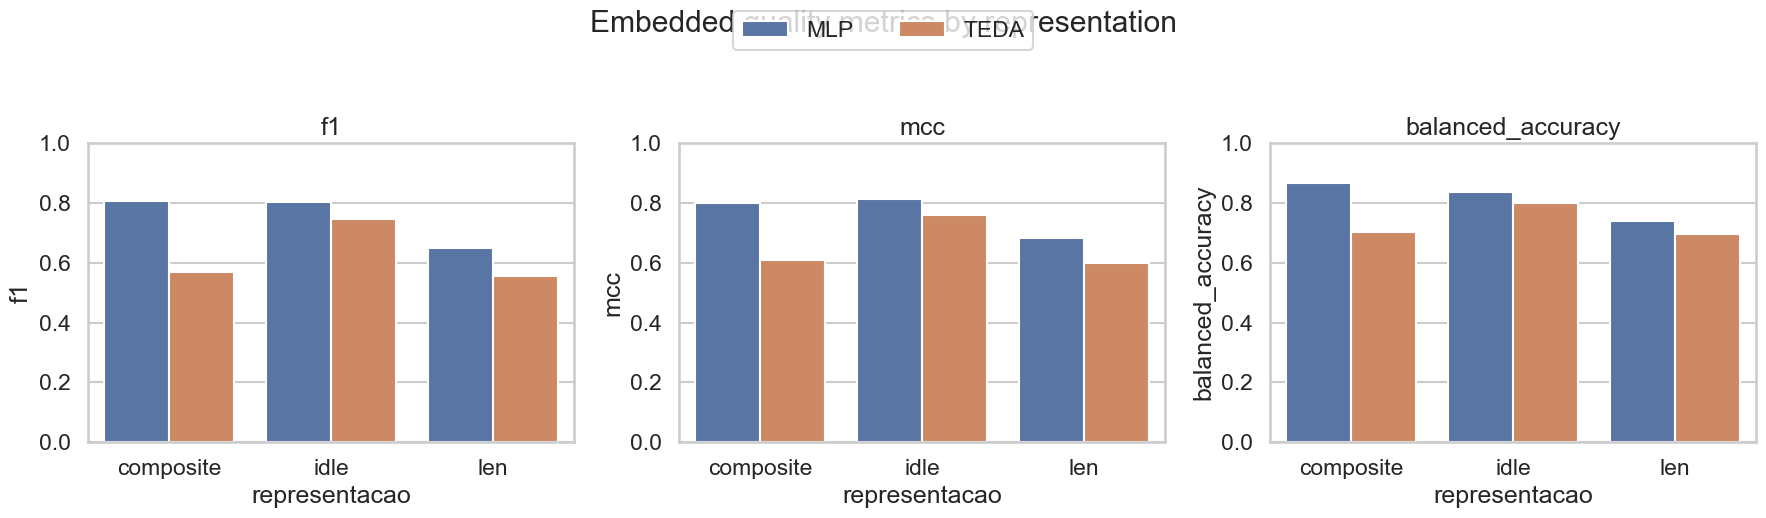

In [70]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)
plot_metrics = ['f1', 'mcc', 'balanced_accuracy']
for ax, metric in zip(axes, plot_metrics):
    if sns is not None:
        sns.barplot(data=results_df, x='representacao', y=metric, hue='modelo', ax=ax)
        ax.legend_.remove()
    else:
        pivot = results_df.pivot(index='representacao', columns='modelo', values=metric)
        pivot.plot(kind='bar', ax=ax)
        if ax.legend_ is not None:
            ax.legend_.remove()
    ax.set_title(metric)
    ax.set_ylim(0, 1)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2)
fig.suptitle('Embedded quality metrics by representation', y=1.05)
fig.tight_layout()
plt.show()


In [71]:
comparison_df = (
    results_df
    .pivot(index='representacao', columns='modelo', values=['f1', 'mcc', 'accuracy', 'balanced_accuracy', 'false_alarm_rate', 'objective_score'])
)
comparison_df

f1                 mcc            accuracy            \
modelo              MLP      TEDA       MLP      TEDA       MLP      TEDA   
representacao                                                               
composite      0.805833  0.567546  0.799700  0.608772  0.980798  0.966695   
idle           0.804238  0.746476  0.812132  0.760769  0.982265  0.977967   
len            0.650144  0.556027  0.682570  0.600584  0.971880  0.966155   

              balanced_accuracy           false_alarm_rate            \
modelo                      MLP      TEDA              MLP      TEDA   
representacao                                                          
composite              0.865835  0.701520         0.005262  0.001152   
idle                   0.836836  0.799744         0.000102  0.000423   
len                    0.741520  0.695473         0.000189  0.001025   

              objective_score            
modelo                    MLP      TEDA  
representacao                            
composite            1.020450  0.742522  
idle                 1.013411  0.946264  
len                  0.835458  0.729536

## Offline-Equivalent Test Split

This section reconstructs the same temporal `idx_test` used offline and recomputes the embedded metrics restricted to that exact window range.


In [72]:
num_windows_total = int(results_df['label_rows'].iloc[0] - WINDOW_SIZE + 1)
split = prepare_temporal_split(num_windows_total, 300)
idx_test_set = set(int(x) for x in split.idx_test)

print({
    'num_windows_total': num_windows_total,
    'idx_test_len': len(split.idx_test),
    'idx_test_first': int(split.idx_test[0]),
    'idx_test_last': int(split.idx_test[-1]),
})

{'num_windows_total': 207625, 'idx_test_len': 83050, 'idx_test_first': 124575, 'idx_test_last': 207624}


In [73]:
test_split_records = []

for _, row in run_table.iterrows():
    infer_df = infer_frames[(row['model'], row['rep'])].copy()
    infer_test_df = infer_df.loc[infer_df['window_idx'].astype(int).isin(idx_test_set)].copy()
    scores = infer_test_df['score'].astype(float).to_numpy()
    flags = infer_test_df['flag'].astype(int).to_numpy()
    y_true = infer_test_df['y_true'].astype(int).to_numpy()
    metrics = binary_metrics(y_true, flags, scores)
    timing = summarize_timing(infer_test_df)
    test_split_records.append({
        'modelo': row['model'],
        'representacao': row['rep'],
        'features_usadas': row['features_usadas'],
        'teda_threshold': row['teda_threshold'],
        'n_test_windows': int(len(infer_test_df)),
        **metrics,
        **timing,
    })

results_test_split_df = pd.DataFrame(test_split_records).sort_values(['representacao', 'modelo']).reset_index(drop=True)
results_test_split_df

,modelo,representacao,features_usadas,teda_threshold,n_test_windows,precision,recall,f1,false_alarm_rate,accuracy,balanced_accuracy,mcc,avg_precision,objective_score,tp,fp,fn,tn,hist_us_mean,hist_us_median,hist_us_p95,metric_us_mean,metric_us_median,metric_us_p95,feat_us_mean,feat_us_median,feat_us_p95,infer_us_mean,infer_us_median,infer_us_p95,total_us_mean,total_us_median,total_us_p95,duty_pct_mean,duty_pct_median,duty_pct_p95
0,MLP,composite,"js, fro, d_js, d_fro, rare",NaN,83050,0.870168,0.833904,0.851650,0.007915,0.982625,0.912995,0.842642,0.906286,1.077129,4142,618,825,77465,439.882071,434.0,483.55,3986.464624,4048.0,4392.0,64.565057,62.0,89.0,573.343877,576.0,594.0,5085.659193,5148.0,5486.0,508.565919,514.8,548.6
1,TEDA,composite,"js, fro, d_js, d_fro, rare",2.3,83050,1.000000,0.608617,0.756696,0.000000,0.976592,0.804308,0.770605,0.746580,0.957773,3023,0,1944,78083,417.713666,414.0,451.00,3978.710969,4046.0,4400.0,68.106105,65.0,92.0,16.668898,16.0,16.0,4503.542830,4569.0,4923.0,450.354283,456.9,492.3
2,MLP,idle,js,NaN,83050,0.994364,0.568351,0.723290,0.000205,0.973992,0.784073,0.741457,0.652070,0.919236,2823,16,2144,78067,787.604106,769.0,870.00,5872.692342,5856.0,6074.0,156.290921,150.0,177.0,544.307008,546.0,565.0,7382.421192,7368.0,7593.0,738.242119,736.8,759.3
3,TEDA,idle,js,1.9,83050,1.000000,0.497081,0.664067,0.000000,0.969922,0.748540,0.694025,0.597637,0.851202,2469,0,2498,78083,701.694413,709.0,728.00,5996.030391,5986.0,6173.0,164.425551,158.0,185.0,14.413594,14.0,14.0,6896.690789,6888.0,7074.0,689.669079,688.8,707.4
4,MLP,len,"js, fro, d_js, d_fro, rare",NaN,83050,0.993478,0.736058,0.845611,0.000307,0.983925,0.867875,0.847820,0.786853,1.062472,3656,24,1311,78059,322.026285,322.0,353.00,2877.213630,2897.0,3178.0,32.021734,31.0,48.0,615.656689,616.0,636.0,3868.374100,3891.0,4165.0,386.837410,389.1,416.5
5,TEDA,len,"js, fro, d_js, d_fro, rare",2.5,83050,1.000000,0.598550,0.748866,0.000000,0.975990,0.799275,0.763967,0.728405,0.948685,2973,0,1994,78083,316.606562,315.0,352.00,2826.631511,2851.0,3135.0,34.312270,33.0,50.0,16.688682,16.0,16.0,3216.636014,3238.0,3524.0,321.663601,323.8,352.4


In [74]:
display(results_test_split_df[[
    'modelo', 'representacao', 'features_usadas', 'teda_threshold', 'n_test_windows',
    'f1', 'mcc', 'accuracy', 'balanced_accuracy', 'false_alarm_rate', 'precision', 'recall', 'objective_score'
]].sort_values(['representacao', 'modelo']))

,modelo,representacao,features_usadas,teda_threshold,n_test_windows,f1,mcc,accuracy,balanced_accuracy,false_alarm_rate,precision,recall,objective_score
0,MLP,composite,"js, fro, d_js, d_fro, rare",NaN,83050,0.851650,0.842642,0.982625,0.912995,0.007915,0.870168,0.833904,1.077129
1,TEDA,composite,"js, fro, d_js, d_fro, rare",2.3,83050,0.756696,0.770605,0.976592,0.804308,0.000000,1.000000,0.608617,0.957773
2,MLP,idle,js,NaN,83050,0.723290,0.741457,0.973992,0.784073,0.000205,0.994364,0.568351,0.919236
3,TEDA,idle,js,1.9,83050,0.664067,0.694025,0.969922,0.748540,0.000000,1.000000,0.497081,0.851202
4,MLP,len,"js, fro, d_js, d_fro, rare",NaN,83050,0.845611,0.847820,0.983925,0.867875,0.000307,0.993478,0.736058,1.062472
5,TEDA,len,"js, fro, d_js, d_fro, rare",2.5,83050,0.748866,0.763967,0.975990,0.799275,0.000000,1.000000,0.598550,0.948685


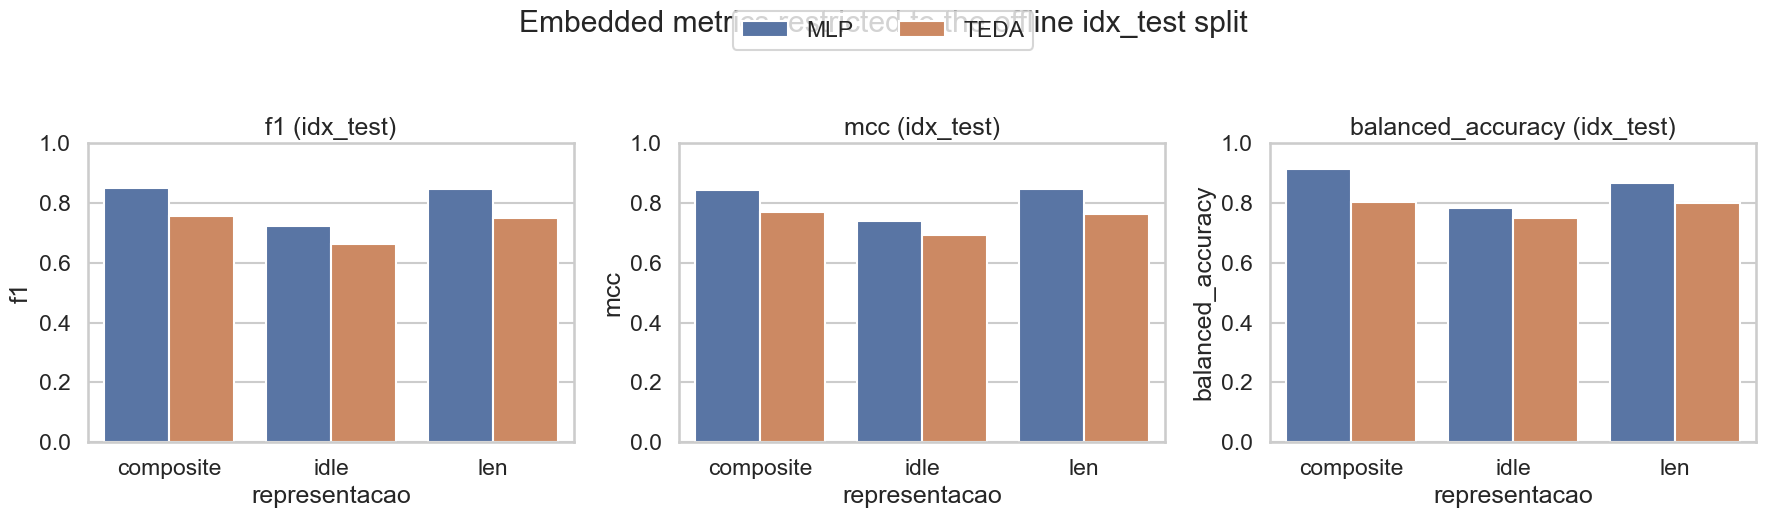

In [75]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)
plot_metrics = ['f1', 'mcc', 'balanced_accuracy']
for ax, metric in zip(axes, plot_metrics):
    if sns is not None:
        sns.barplot(data=results_test_split_df, x='representacao', y=metric, hue='modelo', ax=ax)
        ax.legend_.remove()
    else:
        pivot = results_test_split_df.pivot(index='representacao', columns='modelo', values=metric)
        pivot.plot(kind='bar', ax=ax)
        if ax.legend_ is not None:
            ax.legend_.remove()
    ax.set_title(f'{metric} (idx_test)')
    ax.set_ylim(0, 1)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2)
fig.suptitle('Embedded metrics restricted to the offline idx_test split', y=1.05)
fig.tight_layout()
plt.show()

## On-device Cost

The next section compares latency and duty cycle using only `phase == 'infer'` windows.

In [76]:
time_cols = [
    'modelo', 'representacao',
    'hist_us_mean', 'metric_us_mean', 'feat_us_mean', 'infer_us_mean', 'total_us_mean', 'duty_pct_mean',
    'infer_us_p95', 'total_us_p95', 'duty_pct_p95'
]
display(results_df[time_cols].sort_values(['representacao', 'modelo']))

,modelo,representacao,hist_us_mean,metric_us_mean,feat_us_mean,infer_us_mean,total_us_mean,duty_pct_mean,infer_us_p95,total_us_p95,duty_pct_p95
0,MLP,composite,437.306493,3993.831271,64.556655,573.495018,5090.615089,509.061509,594.0,5478.0,547.8
1,TEDA,composite,415.213152,3986.278069,68.143528,16.655620,4508.656879,450.865688,16.0,4915.0,491.5
2,MLP,idle,785.113618,5871.655591,156.290504,544.368680,7378.976776,737.897678,565.0,7585.0,758.5
3,TEDA,idle,699.134257,5995.523219,164.375544,14.398869,6893.569277,689.356928,14.0,7064.0,706.4
4,MLP,len,319.363379,2893.475319,32.038080,615.812981,3882.153541,388.215354,636.0,4170.0,417.0
5,TEDA,len,313.967838,2843.280606,34.321204,16.673210,3230.647097,323.064710,16.0,3526.0,352.6


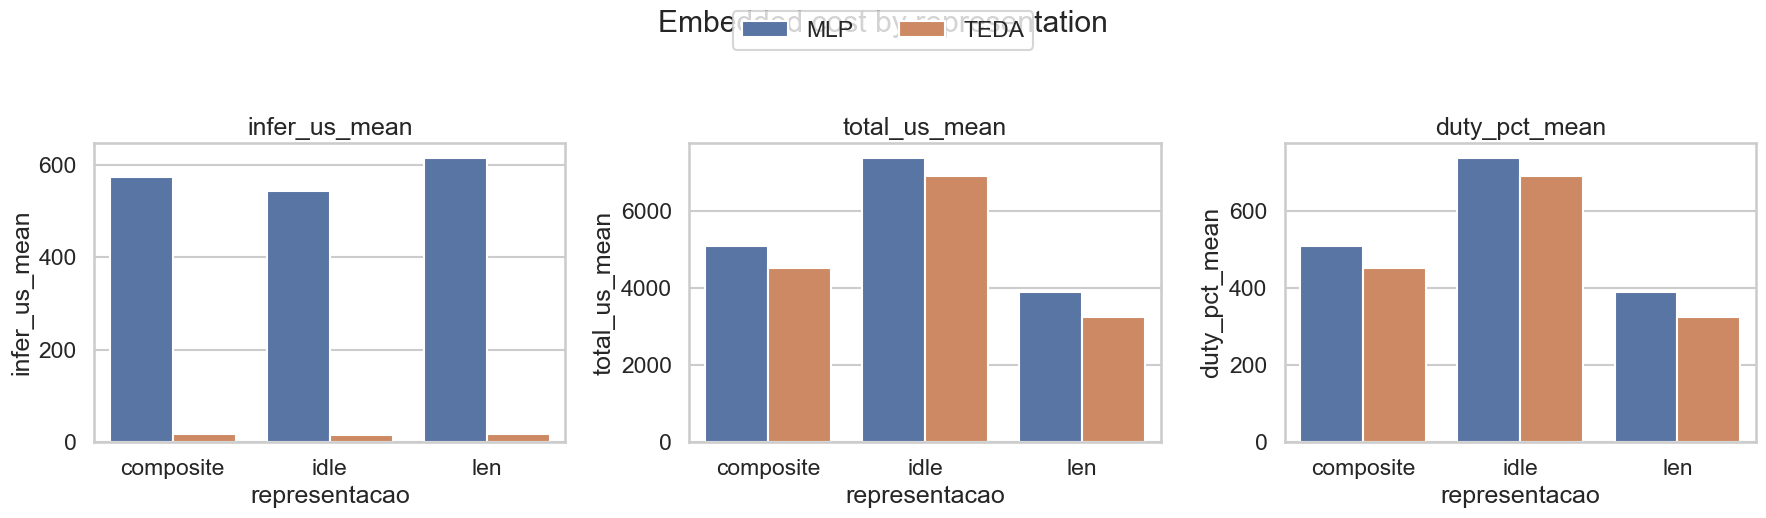

In [77]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)
plot_metrics = ['infer_us_mean', 'total_us_mean', 'duty_pct_mean']
for ax, metric in zip(axes, plot_metrics):
    if sns is not None:
        sns.barplot(data=results_df, x='representacao', y=metric, hue='modelo', ax=ax)
        ax.legend_.remove()
    else:
        pivot = results_df.pivot(index='representacao', columns='modelo', values=metric)
        pivot.plot(kind='bar', ax=ax)
        if ax.legend_ is not None:
            ax.legend_.remove()
    ax.set_title(metric)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2)
fig.suptitle('Embedded cost by representation', y=1.05)
fig.tight_layout()
plt.show()


## Temporal Behaviour

This section overlays the score and the ground-truth anomaly windows for each representation, allowing a direct visual comparison between MLP and TEDA.

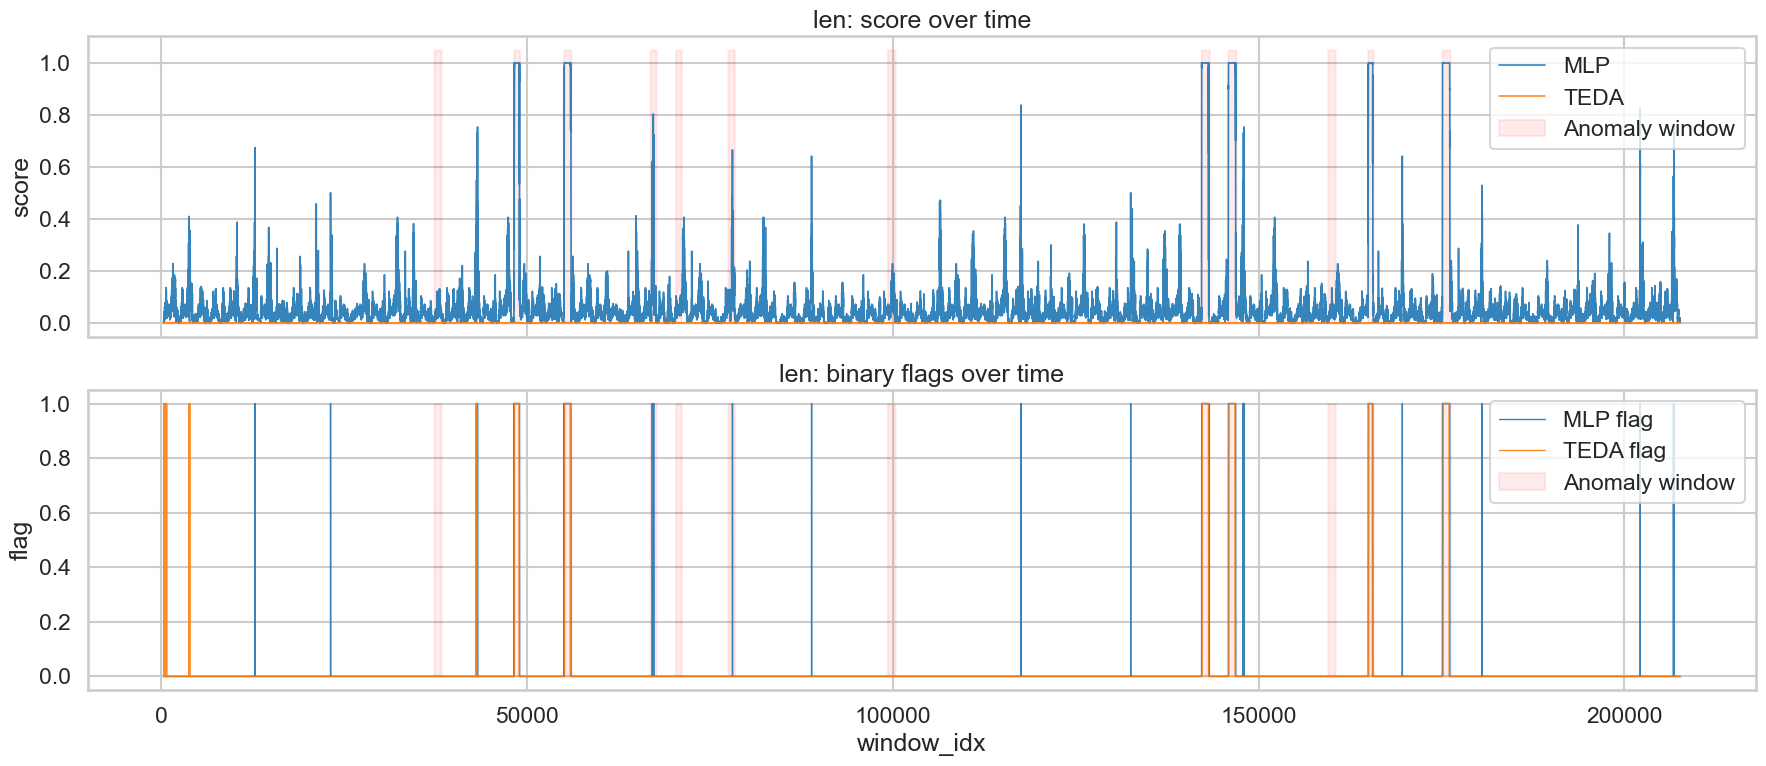

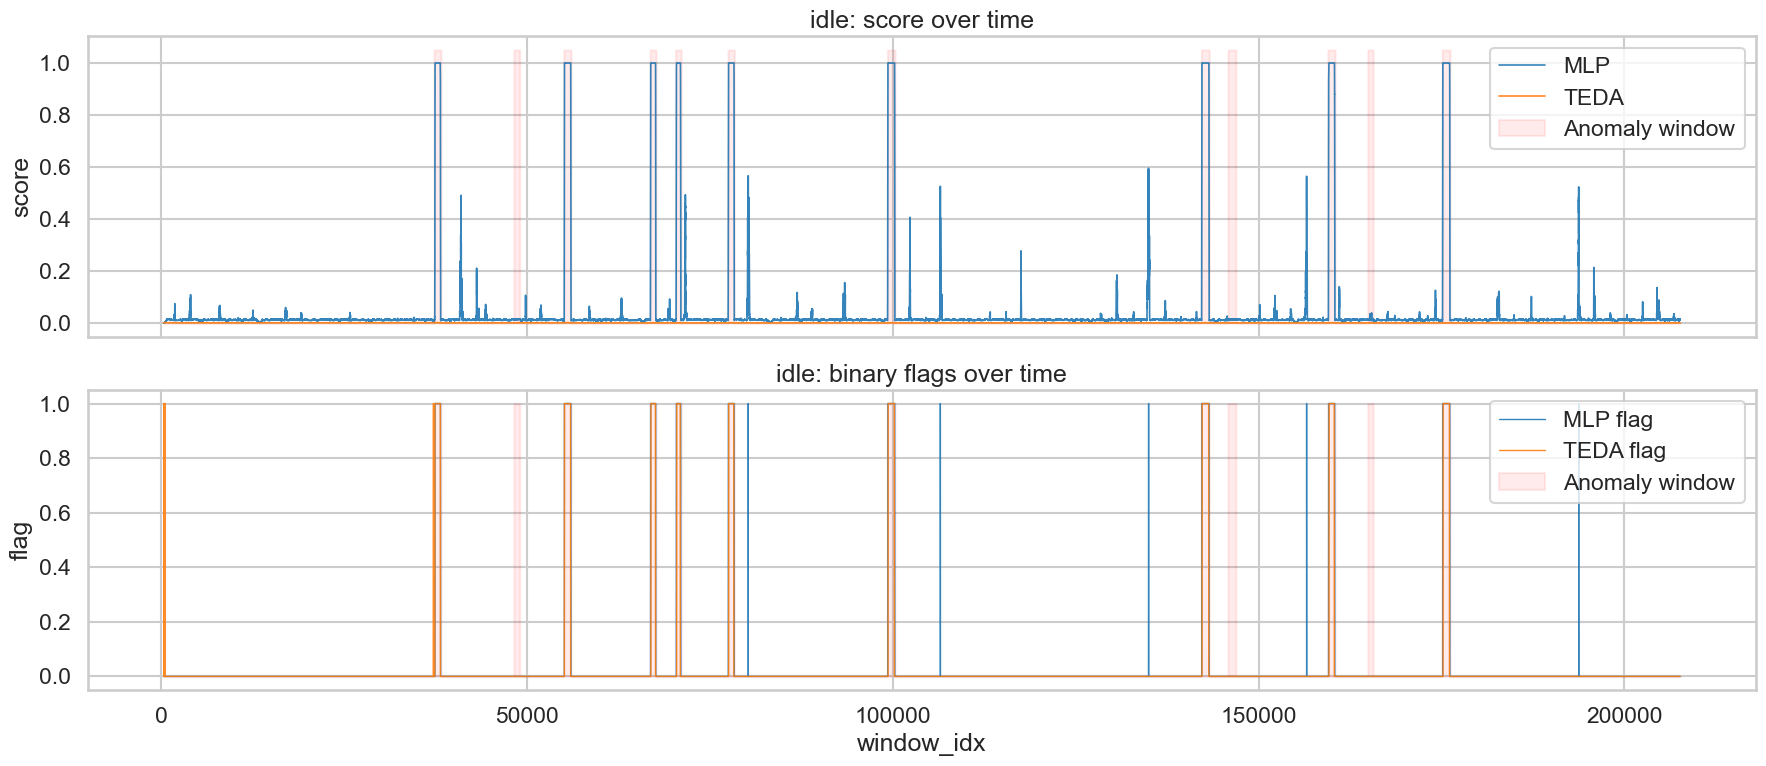

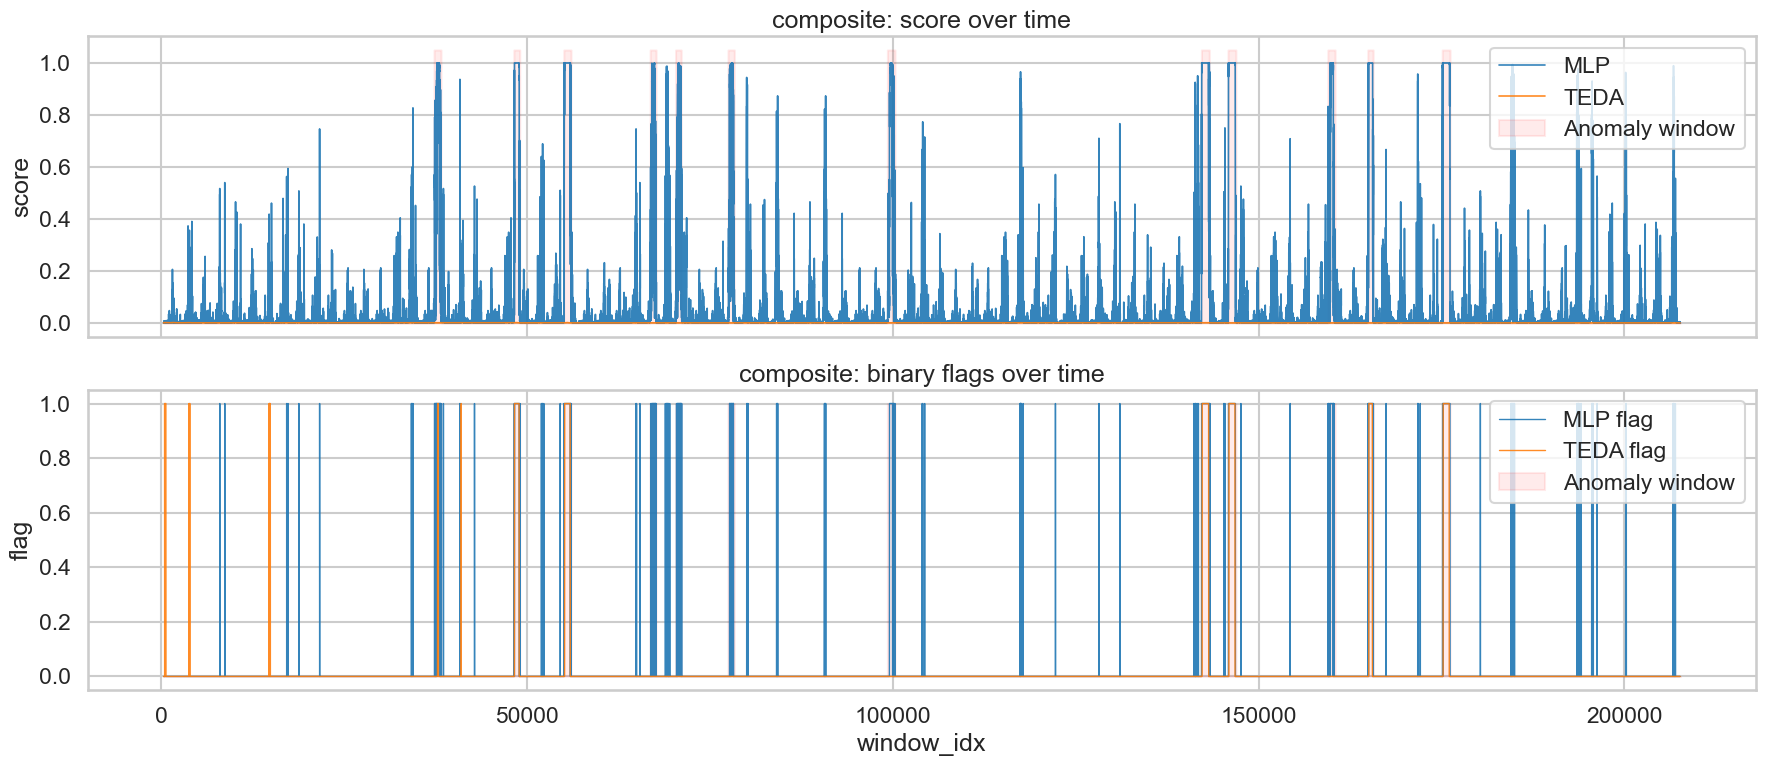

In [78]:
def plot_temporal_comparison(rep_name: str, score_clip_quantile: float = 0.995):
    fig, axes = plt.subplots(2, 1, figsize=(18, 8), sharex=True)
    for model_name, color in [('MLP', 'tab:blue'), ('TEDA', 'tab:orange')]:
        infer_df = infer_frames[(model_name, rep_name)].copy()
        infer_df['score_clipped'] = infer_df['score'].clip(upper=infer_df['score'].quantile(score_clip_quantile))
        axes[0].plot(infer_df['window_idx'], infer_df['score_clipped'], label=model_name, alpha=0.9, linewidth=1.2, color=color)
        axes[1].plot(infer_df['window_idx'], infer_df['flag'], label=f'{model_name} flag', alpha=0.9, linewidth=1.0, color=color)

    y_true = infer_frames[('MLP', rep_name)]['y_true'].to_numpy()
    window_idx = infer_frames[('MLP', rep_name)]['window_idx'].to_numpy()
    axes[0].fill_between(window_idx, 0, y_true * axes[0].get_ylim()[1] if len(window_idx) else 0, color='red', alpha=0.08, step='pre', label='Anomaly window')
    axes[1].fill_between(window_idx, 0, y_true, color='red', alpha=0.08, step='pre', label='Anomaly window')

    axes[0].set_title(f'{rep_name}: score over time')
    axes[0].set_ylabel('score')
    axes[1].set_title(f'{rep_name}: binary flags over time')
    axes[1].set_ylabel('flag')
    axes[1].set_xlabel('window_idx')
    axes[1].set_ylim(-0.05, 1.05)
    axes[0].legend(loc='upper right')
    axes[1].legend(loc='upper right')
    fig.tight_layout()
    plt.show()

for rep_name in ['len', 'idle', 'composite']:
    plot_temporal_comparison(rep_name)

## Advanced Visual Analysis

The following views use less conventional chart types to explore trade-offs, distributions, ranking changes, and disagreement patterns between `MLP` and `TEDA`.

### Pipeline Stage Comparison

These two views focus specifically on the contribution of each pipeline stage: a dumbbell chart for absolute time and a heatmap for relative participation.


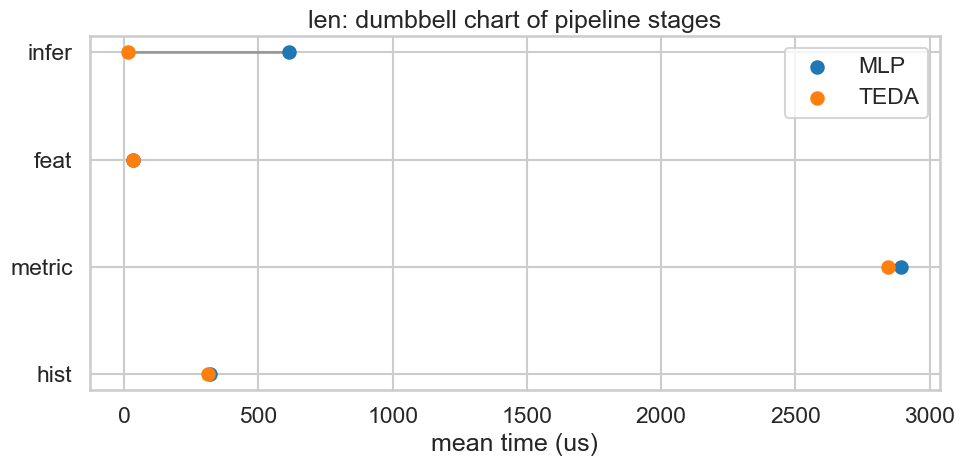

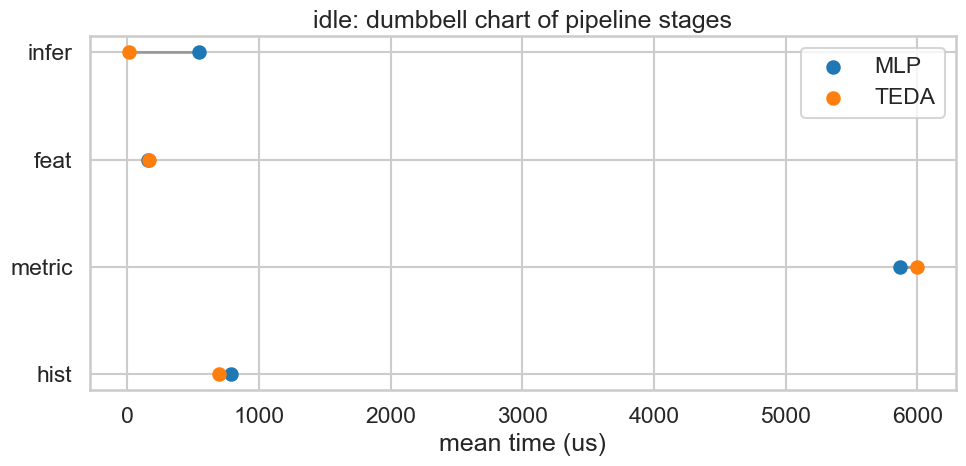

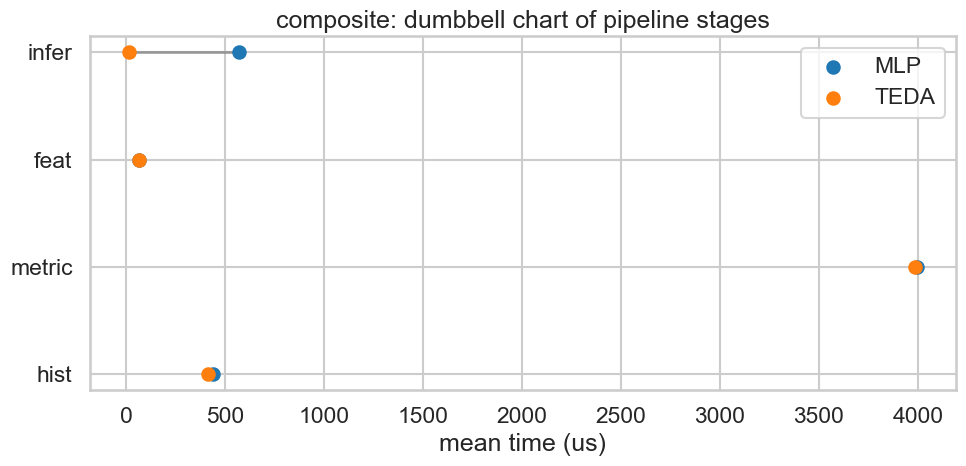

In [79]:
rep_order_stage = ['len', 'idle', 'composite']
model_colors_stage = {'MLP': '#1f77b4', 'TEDA': '#ff7f0e'}
stage_cols = ['hist_us_mean', 'metric_us_mean', 'feat_us_mean', 'infer_us_mean']
stage_labels = {
    'hist_us_mean': 'hist',
    'metric_us_mean': 'metric',
    'feat_us_mean': 'feat',
    'infer_us_mean': 'infer',
}

for rep_name in rep_order_stage:
    rep_df = results_df.loc[results_df['representacao'] == rep_name].set_index('modelo')
    fig, ax = plt.subplots(figsize=(10, 5))
    y = np.arange(len(stage_cols))
    mlp_vals = rep_df.loc['MLP', stage_cols].to_numpy(dtype=float)
    teda_vals = rep_df.loc['TEDA', stage_cols].to_numpy(dtype=float)

    for yi, x0, x1 in zip(y, mlp_vals, teda_vals):
        ax.plot([x0, x1], [yi, yi], color='gray', linewidth=2, alpha=0.7)
    ax.scatter(mlp_vals, y, color=model_colors_stage['MLP'], s=80, label='MLP', zorder=3)
    ax.scatter(teda_vals, y, color=model_colors_stage['TEDA'], s=80, label='TEDA', zorder=3)

    ax.set_yticks(y)
    ax.set_yticklabels([stage_labels[c] for c in stage_cols])
    ax.set_xlabel('mean time (us)')
    ax.set_title(f'{rep_name}: dumbbell chart of pipeline stages')
    ax.legend()
    plt.tight_layout()
    plt.show()

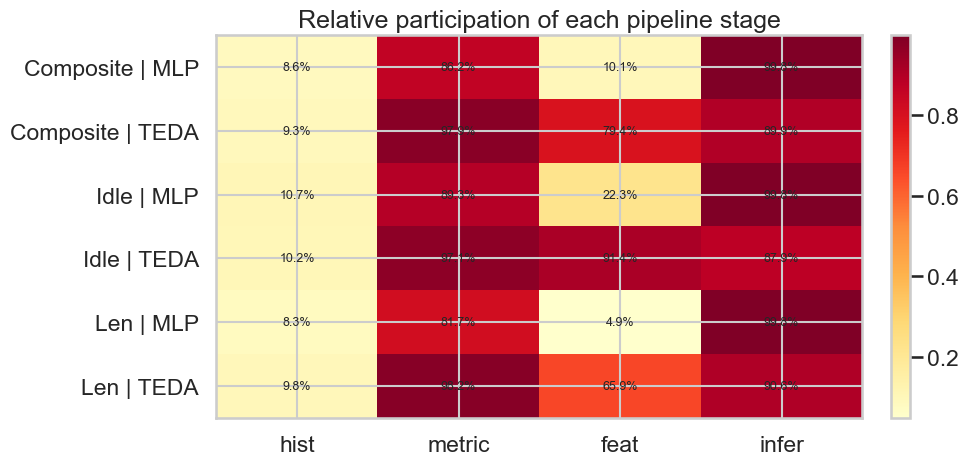

In [80]:
stage_cols = ['hist_us_mean', 'metric_us_mean', 'feat_us_mean', 'infer_us_mean']
stage_labels = {
    'hist_us_mean': 'hist',
    'metric_us_mean': 'metric',
    'feat_us_mean': 'feat',
    'infer_us_mean': 'infer',
}
heatmap_df = results_df[['modelo', 'representacao'] + stage_cols].copy()
heatmap_df['label'] = heatmap_df['representacao'].str.capitalize() + ' | ' + heatmap_df['modelo']
for col in stage_cols:
    heatmap_df[col] = heatmap_df[col] / heatmap_df[stage_cols].sum(axis=1)

heatmap_mat = heatmap_df.set_index('label')[stage_cols].rename(columns=stage_labels)
fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(heatmap_mat.to_numpy(), aspect='auto', cmap='YlOrRd')
ax.set_xticks(np.arange(len(heatmap_mat.columns)))
ax.set_xticklabels(list(heatmap_mat.columns))
ax.set_yticks(np.arange(len(heatmap_mat.index)))
ax.set_yticklabels(list(heatmap_mat.index))
ax.set_title('Relative participation of each pipeline stage')
for r in range(heatmap_mat.shape[0]):
    for c in range(heatmap_mat.shape[1]):
        ax.text(c, r, f"{heatmap_mat.iloc[r, c]*100:.1f}%", ha='center', va='center', fontsize=9)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

### Grouped Vertical Bars: Stage Time and Relative Share

Grouped bars provide a more presentation-friendly comparison of absolute and relative stage costs.


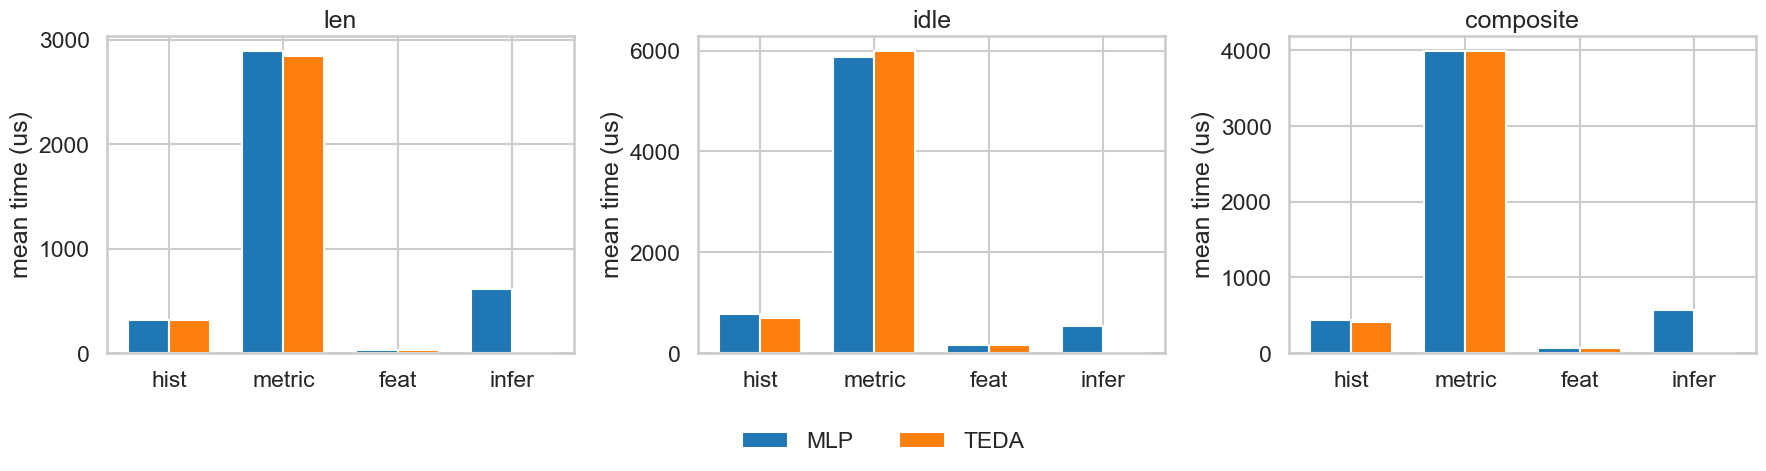

In [81]:
rep_order_stage = ['len', 'idle', 'composite']
stage_cols = ['hist_us_mean', 'metric_us_mean', 'feat_us_mean', 'infer_us_mean']
stage_labels = ['hist', 'metric', 'feat', 'infer']
model_colors_stage = {'MLP': '#1f77b4', 'TEDA': '#ff7f0e'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
bar_width = 0.36
x = np.arange(len(stage_cols))

for ax, rep_name in zip(axes, rep_order_stage):
    rep_df = results_df.loc[results_df['representacao'] == rep_name].set_index('modelo')
    mlp_vals = rep_df.loc['MLP', stage_cols].to_numpy(dtype=float)
    teda_vals = rep_df.loc['TEDA', stage_cols].to_numpy(dtype=float)

    ax.bar(x - bar_width / 2, mlp_vals, width=bar_width, color=model_colors_stage['MLP'], label='MLP')
    ax.bar(x + bar_width / 2, teda_vals, width=bar_width, color=model_colors_stage['TEDA'], label='TEDA')
    ax.set_xticks(x)
    ax.set_xticklabels(stage_labels)
    ax.set_title(rep_name)
    ax.set_ylabel('mean time (us)')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.03),
    ncol=2,
    frameon=False
)

# fig.suptitle('Grouped bars: absolute mean time by pipeline stage', y=1.02)
fig.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.show()

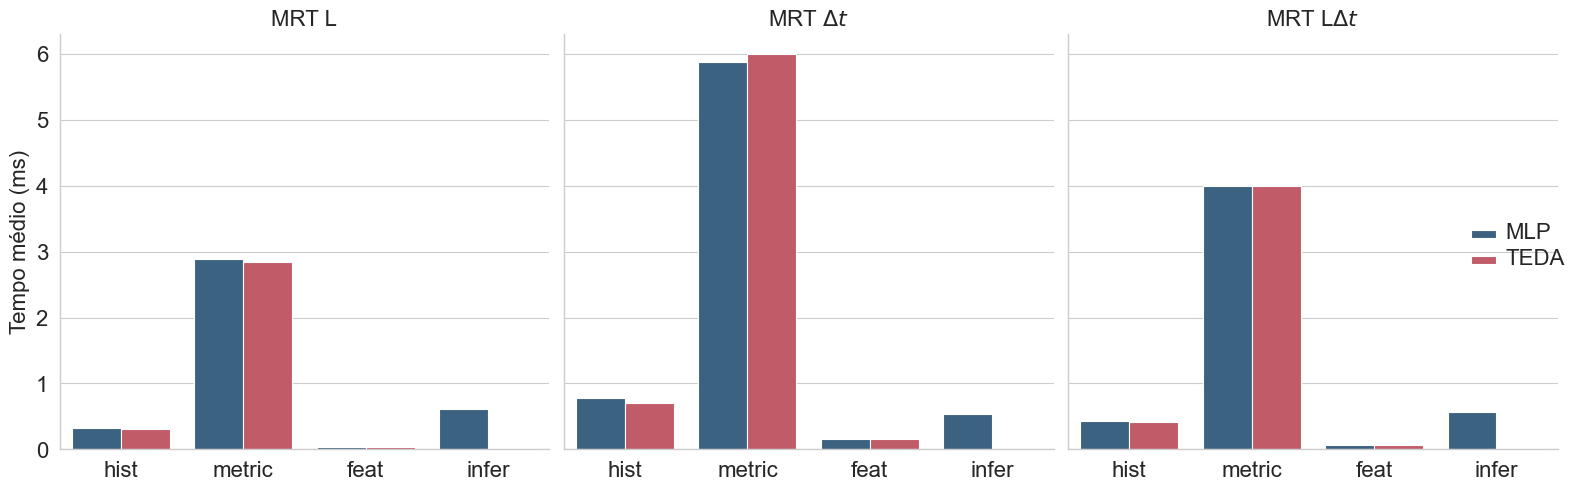

In [94]:
import matplotlib.pyplot as plt

if sns is not None:
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.0)
else:
    plt.style.use('ggplot')

rep_order_stage = ['len', 'idle', 'composite']
stage_cols = ['hist_us_mean', 'metric_us_mean', 'feat_us_mean', 'infer_us_mean']
stage_labels = ['hist', 'metric', 'feat', 'infer']

# Converter para long format
df_long = results_df.melt(
    id_vars=['representacao', 'modelo'],
    value_vars=stage_cols,
    var_name='stage',
    value_name='time_us'
)

# Mapear nomes das etapas
stage_map = dict(zip(stage_cols, stage_labels))
df_long['stage'] = df_long['stage'].map(stage_map)

# Converter de microssegundos para milissegundos
df_long['time_ms'] = df_long['time_us'] / 1000.0

# Mapear nomes das representações
rep_map = {
    'len': r'MRT L',
    'idle': r'MRT $\Delta t$',
    'composite': r'MRT L$\Delta t$'
}
df_long['representacao_label'] = df_long['representacao'].map(rep_map)

if sns is not None:
    g = sns.catplot(
        data=df_long,
        kind="bar",
        x="stage",
        y="time_ms",
        hue="modelo",
        col="representacao_label",
        col_order=[rep_map[r] for r in rep_order_stage],
        palette={
            'MLP': '#30638E',
            'TEDA': '#D14A5B'
        },
        height=5,
        aspect=1
    )

    g.set_axis_labels("", "Tempo médio (ms)")
    g.set_titles("{col_name}")
    g._legend.set_title("")

    for ax in g.axes.flat:
        ax.set_xlabel(ax.get_xlabel(), fontsize=16)
        ax.set_ylabel(ax.get_ylabel(), fontsize=16)
        ax.set_title(ax.get_title(), fontsize=16)
        ax.tick_params(axis='both', labelsize=16)

    if g._legend is not None:
        for text in g._legend.texts:
            text.set_fontsize(16)

    plt.tight_layout()
    plt.show()
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    colors = {'MLP': '#30638E', 'TEDA': '#D14A5B'}
    for ax, rep_name in zip(axes, rep_order_stage):
        sub = df_long[df_long['representacao'] == rep_name].copy()
        pivot = sub.pivot(index='stage', columns='modelo', values='time_ms').reindex(stage_labels)
        x = np.arange(len(stage_labels))
        width = 0.36
        for offset, model in [(-width / 2, 'MLP'), (width / 2, 'TEDA')]:
            if model in pivot.columns:
                ax.bar(x + offset, pivot[model].to_numpy(dtype=float), width=width, color=colors[model], label=model)
        ax.set_xticks(x)
        ax.set_xticklabels(stage_labels)
        ax.set_title(rep_map[rep_name], fontsize=16)
        ax.set_ylabel('Tempo médio (ms)', fontsize=16)
        ax.tick_params(axis='both', labelsize=14)
        ax.grid(axis='y', alpha=0.3)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False)
    fig.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()

In [83]:
pipeline_rows = []

for (modelo, representacao), df in infer_frames.items():
    tmp = df[['hist_us', 'metric_us', 'feat_us', 'infer_us', 'total_us', 'duty_pct']].copy()
    tmp['modelo'] = modelo
    tmp['representacao'] = representacao
    pipeline_rows.append(tmp)

pipeline_window_df = pd.concat(pipeline_rows, ignore_index=True)

pipeline_describe = (
    pipeline_window_df
    .groupby(['modelo', 'representacao'])[['hist_us', 'metric_us', 'feat_us', 'infer_us', 'total_us', 'duty_pct']]
    .agg(['mean', 'std', 'min', 'max'])
    .round(2)
)

display(pipeline_describe)


hist_us                  metric_us                      \
                        mean    std  min  max      mean     std   min   max   
modelo representacao                                                          
MLP    composite      437.31  23.00  398  519   3993.83  315.13  2685  4660   
       idle           785.11  45.19  702  928   5871.66  182.31  5139  7954   
       len            319.36  16.96  289  375   2893.48  208.27  1696  3361   
TEDA   composite      415.21  19.83  379  466   3986.28  334.35  2670  4646   
       idle           699.13  18.01  653  739   5995.52  184.04  5248  8062   
       len            313.97  19.72  282  370   2843.28  216.08  1657  3299   

                     feat_us                  infer_us                  \
                        mean    std  min  max     mean    std min  max   
modelo representacao                                                     
MLP    composite       64.56   8.22   61  107   573.50  16.56   0  596   
       idle           156.29  11.59  149  195   544.37  16.53   0  567   
       len             32.04   5.78   30   76   615.81  17.09   0  638   
TEDA   composite       68.14   8.09   65  111    16.66   4.14   0   61   
       idle           164.38  11.94  157  203    14.40   3.94   0   59   
       len             34.32   5.99   32   78    16.67   4.19   0   61   

                     total_us                      duty_pct                \
                         mean     std   min    max     mean    std    min   
modelo representacao                                                        
MLP    composite      5090.62  314.30  3808   8654   509.06  31.43  380.8   
       idle           7378.98  187.58  6622  12550   737.90  18.76  662.2   
       len            3882.15  208.29  2663   6851   388.22  20.83  266.3   
TEDA   composite      4508.66  334.87  3212   8635   450.87  33.49  321.2   
       idle           6893.57  184.78  6156  10937   689.36  18.48  615.6   
       len            3230.65  215.68  2073   6773   323.06  21.57  207.3   

                              
                         max  
modelo representacao          
MLP    composite       865.4  
       idle           1255.0  
       len             685.1  
TEDA   composite       863.5  
       idle           1093.7  
       len             677.3

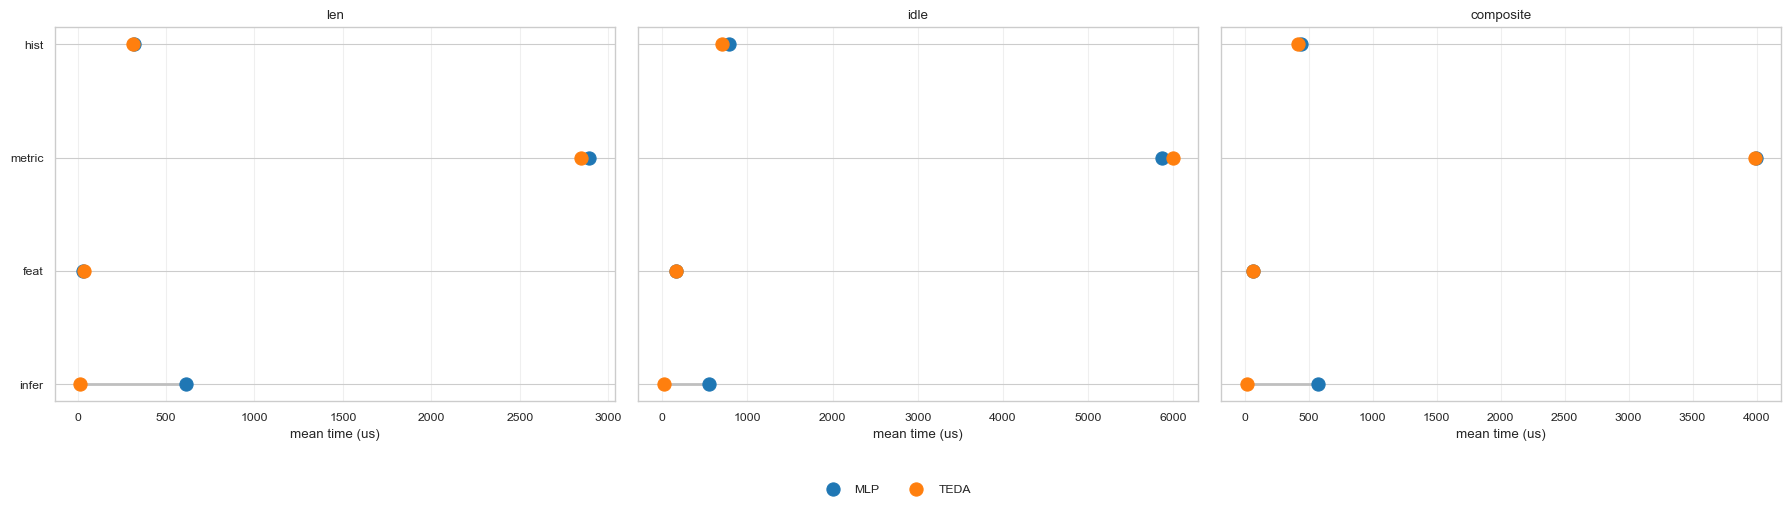

In [84]:
rep_order_stage = ['len', 'idle', 'composite']
stage_cols = ['hist_us_mean', 'metric_us_mean', 'feat_us_mean', 'infer_us_mean']
stage_labels = ['hist', 'metric', 'feat', 'infer']

model_colors_stage = {
    'MLP': '#1f77b4',
    'TEDA': '#ff7f0e'
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=False, sharey=True)

for ax, rep_name in zip(axes, rep_order_stage):
    rep_df = results_df.loc[results_df['representacao'] == rep_name].set_index('modelo')

    mlp_vals = rep_df.loc['MLP', stage_cols].to_numpy(dtype=float)
    teda_vals = rep_df.loc['TEDA', stage_cols].to_numpy(dtype=float)

    y = np.arange(len(stage_cols))

    # linha ligando os dois pontos
    for i in range(len(stage_cols)):
        ax.plot(
            [mlp_vals[i], teda_vals[i]],
            [y[i], y[i]],
            color='0.75',
            linewidth=2,
            zorder=1
        )

    # pontos
    ax.scatter(
        mlp_vals, y,
        s=90,
        color=model_colors_stage['MLP'],
        label='MLP',
        zorder=3
    )
    ax.scatter(
        teda_vals, y,
        s=90,
        color=model_colors_stage['TEDA'],
        label='TEDA',
        zorder=3
    )

    ax.set_yticks(y)
    ax.set_yticklabels(stage_labels)
    ax.invert_yaxis()  # hist em cima, infer embaixo
    ax.set_title(rep_name)
    ax.set_xlabel('mean time (us)')
    ax.grid(axis='x', alpha=0.3)

# legenda única
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles[:2],
    labels[:2],
    loc='lower center',
    bbox_to_anchor=(0.5, -0.02),
    ncol=2,
    frameon=False
)

fig.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

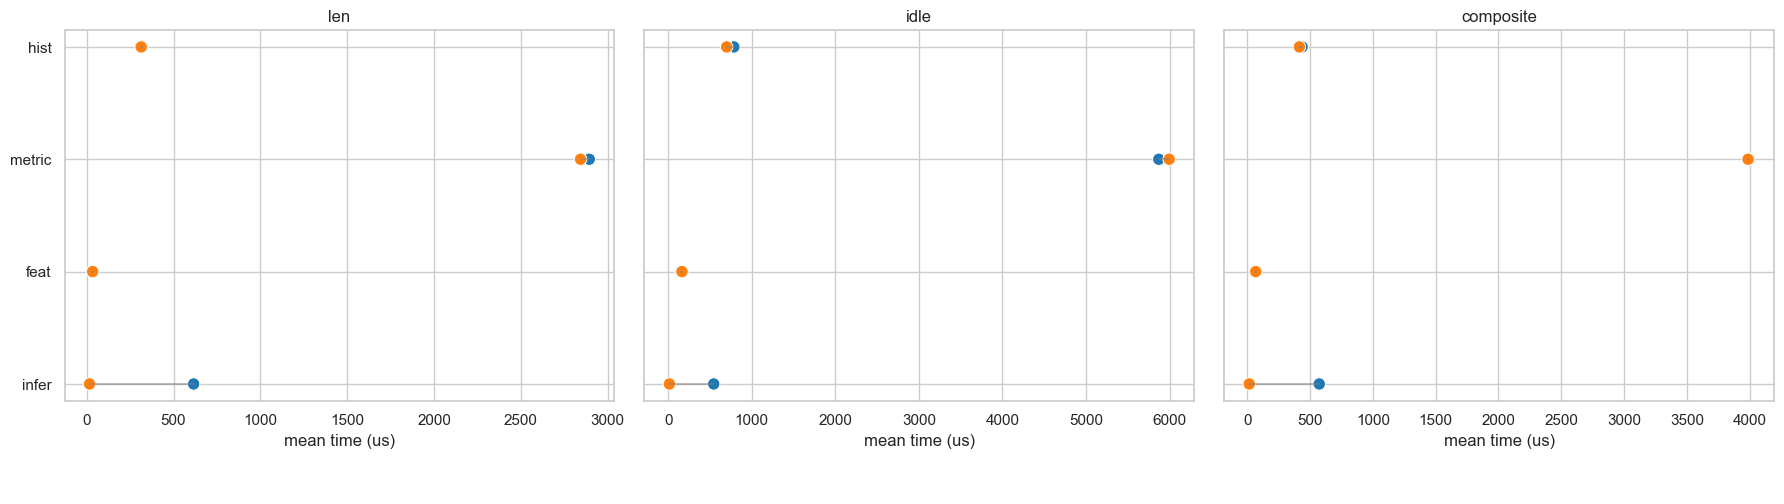

In [85]:
import matplotlib.pyplot as plt

if sns is not None:
    sns.set_theme(style="whitegrid")
else:
    plt.style.use('ggplot')

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, rep in zip(axes, rep_order_stage):
    sub = df_long[df_long['representacao'] == rep]

    if sns is not None:
        sns.scatterplot(
            data=sub,
            x="time_us",
            y="stage",
            hue="modelo",
            palette={'MLP': '#1f77b4', 'TEDA': '#ff7f0e'},
            s=80,
            ax=ax,
            legend=False
        )
    else:
        for model, color in [('MLP', '#1f77b4'), ('TEDA', '#ff7f0e')]:
            points = sub[sub['modelo'] == model]
            ax.scatter(points['time_us'], points['stage'], color=color, s=80, label=model)

    # ligar os pontos (dumbbell)
    for stage in stage_labels:
        vals = sub[sub['stage'] == stage]
        if len(vals) == 2:
            x1 = vals.iloc[0]['time_us']
            x2 = vals.iloc[1]['time_us']
            ax.plot([x1, x2], [stage, stage], color='gray', alpha=0.5)

    ax.set_title(rep)
    ax.set_xlabel("mean time (us)")
    ax.set_ylabel("")

# legenda manual
handles, labels = axes[0].get_legend_handles_labels()
if labels:
    unique = dict(zip(labels, handles))
    handles = list(unique.values())
    labels = list(unique.keys())
fig.legend(
    handles,
    labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.02),
    ncol=2,
    frameon=False
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

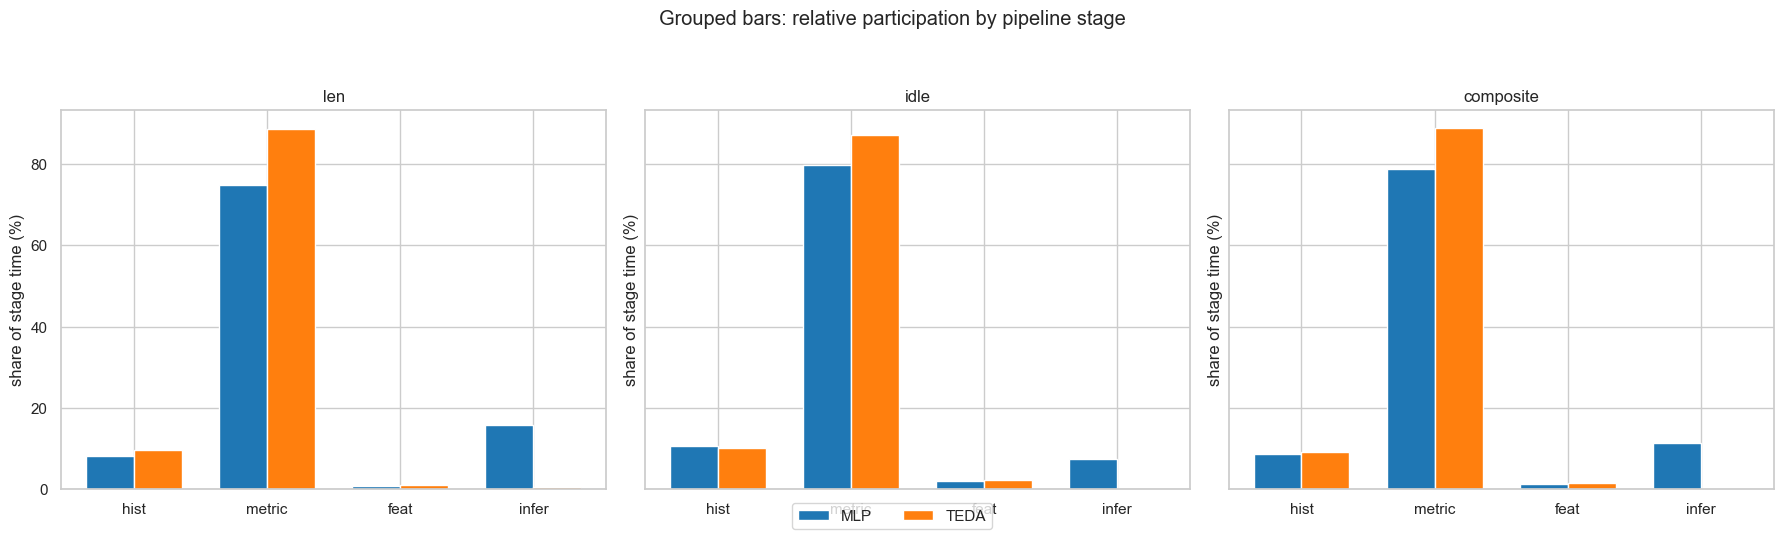

In [86]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
bar_width = 0.36
x = np.arange(len(stage_cols))

for ax, rep_name in zip(axes, rep_order_stage):
    rep_df = results_df.loc[results_df['representacao'] == rep_name].set_index('modelo')
    mlp_vals = rep_df.loc['MLP', stage_cols].to_numpy(dtype=float)
    teda_vals = rep_df.loc['TEDA', stage_cols].to_numpy(dtype=float)
    mlp_share = mlp_vals / mlp_vals.sum()
    teda_share = teda_vals / teda_vals.sum()
    ax.bar(x - bar_width / 2, mlp_share * 100.0, width=bar_width, color=model_colors_stage['MLP'], label='MLP')
    ax.bar(x + bar_width / 2, teda_share * 100.0, width=bar_width, color=model_colors_stage['TEDA'], label='TEDA')
    ax.set_xticks(x)
    ax.set_xticklabels(stage_labels)
    ax.set_title(rep_name)
    ax.set_ylabel('share of stage time (%)')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2)
fig.suptitle('Grouped bars: relative participation by pipeline stage', y=1.05)
fig.tight_layout()
plt.show()

### Connected Scatter: Quality vs Cost

Each line connects `len -> idle -> composite` for one model, revealing how the quality/cost trade-off changes across representations.

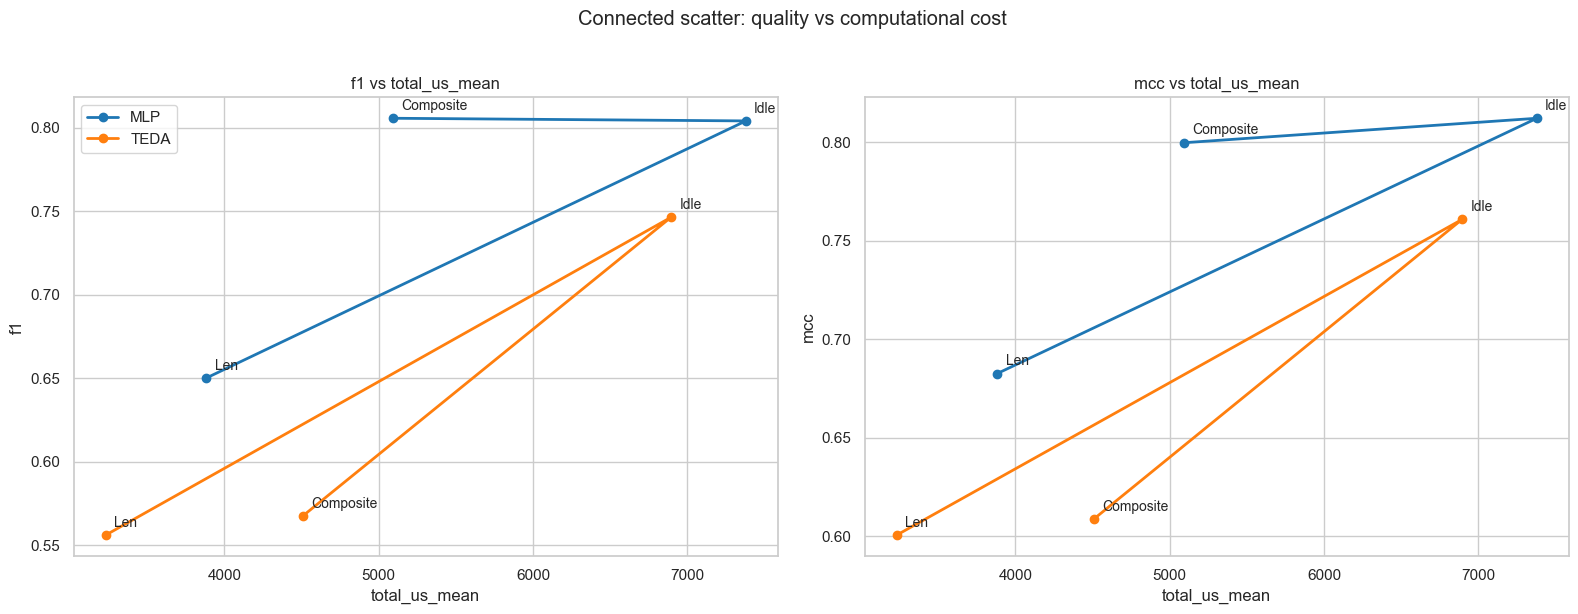

In [87]:
rep_order = ['len', 'idle', 'composite']
rep_labels = {'len': 'Len', 'idle': 'Idle', 'composite': 'Composite'}
model_colors = {'MLP': '#1f77b4', 'TEDA': '#ff7f0e'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for model_name in ['MLP', 'TEDA']:
    dfm = results_df.loc[results_df['modelo'] == model_name].copy()
    dfm['rep_order'] = dfm['representacao'].map({r: i for i, r in enumerate(rep_order)})
    dfm = dfm.sort_values('rep_order')
    for ax, y_col in zip(axes, ['f1', 'mcc']):
        ax.plot(dfm['total_us_mean'], dfm[y_col], marker='o', linewidth=2, color=model_colors[model_name], label=model_name)
        for _, row in dfm.iterrows():
            ax.annotate(rep_labels[row['representacao']], (row['total_us_mean'], row[y_col]), textcoords='offset points', xytext=(6, 6), fontsize=10)
        ax.set_xlabel('total_us_mean')
        ax.set_ylabel(y_col)
        ax.set_title(f'{y_col} vs total_us_mean')
axes[0].legend()
fig.suptitle('Connected scatter: quality vs computational cost', y=1.02)
fig.tight_layout()
plt.show()

### Difference Chart: Score Gap Over Time

The filled area highlights where `MLP` scores above `TEDA` and where the reverse happens.

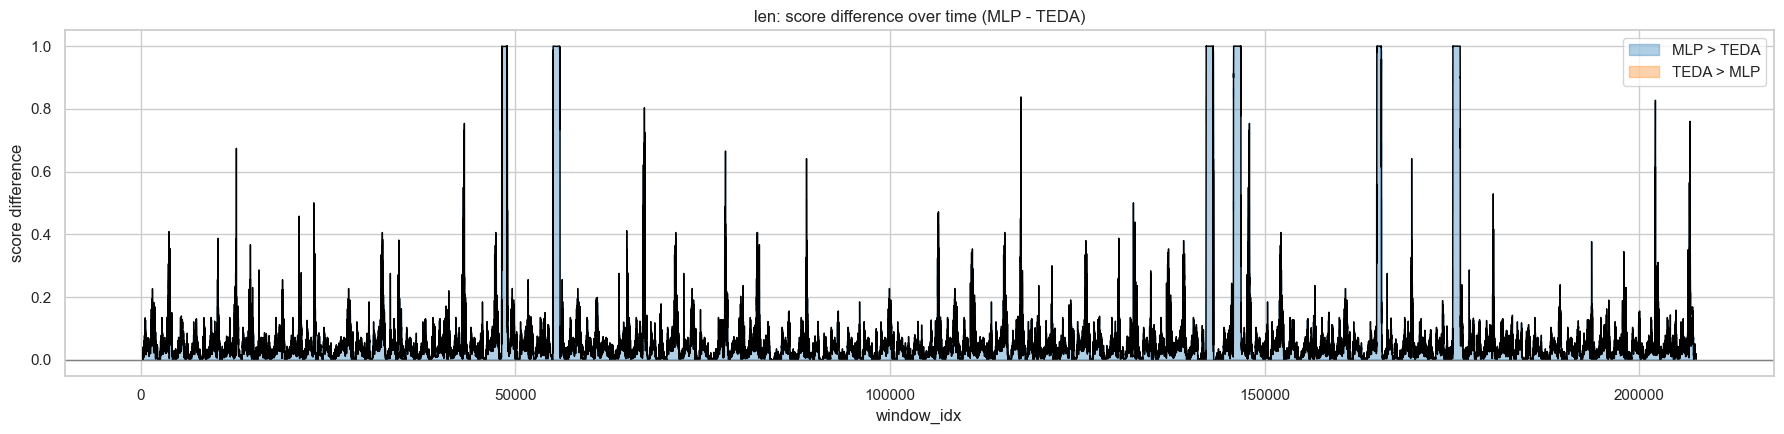

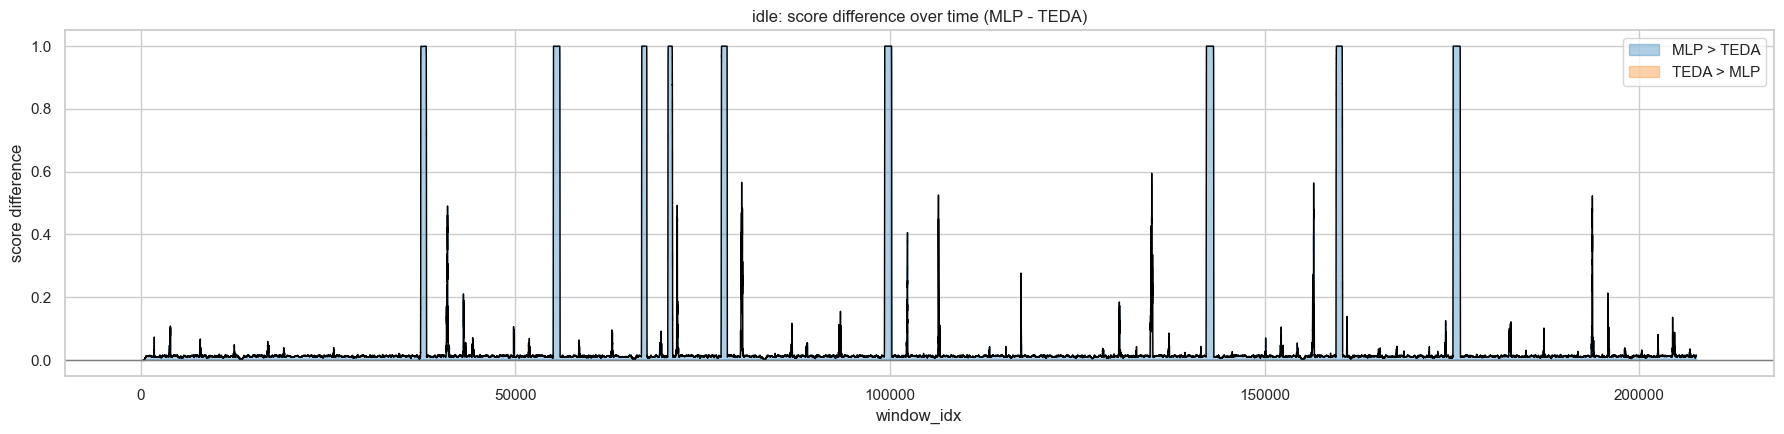

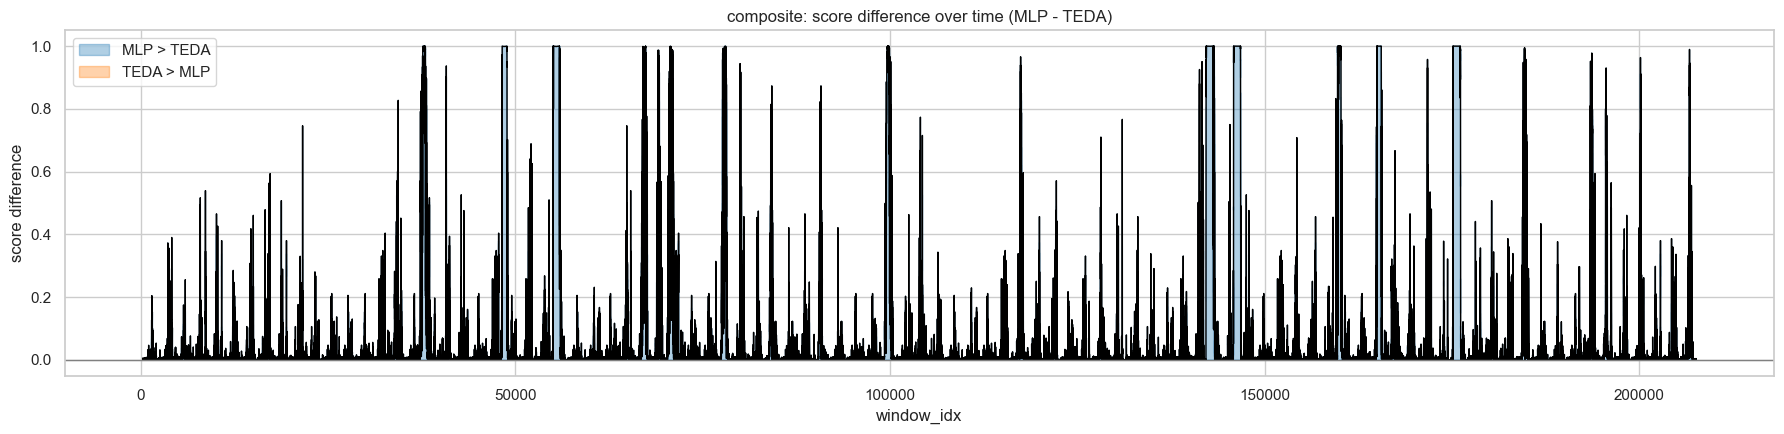

In [88]:
def plot_difference_chart(rep_name: str, score_clip_quantile: float = 0.995):
    mlp = infer_frames[('MLP', rep_name)][['window_idx', 'score']].copy().rename(columns={'score': 'score_mlp'})
    teda = infer_frames[('TEDA', rep_name)][['window_idx', 'score']].copy().rename(columns={'score': 'score_teda'})
    df = mlp.merge(teda, on='window_idx', how='inner')
    df['score_mlp'] = df['score_mlp'].clip(upper=df['score_mlp'].quantile(score_clip_quantile))
    df['score_teda'] = df['score_teda'].clip(upper=df['score_teda'].quantile(score_clip_quantile))
    df['diff'] = df['score_mlp'] - df['score_teda']

    plt.figure(figsize=(18, 4.5))
    plt.plot(df['window_idx'], df['diff'], color='black', linewidth=1)
    plt.fill_between(df['window_idx'], 0, df['diff'], where=df['diff'] >= 0, color='#1f77b4', alpha=0.35, label='MLP > TEDA')
    plt.fill_between(df['window_idx'], 0, df['diff'], where=df['diff'] < 0, color='#ff7f0e', alpha=0.35, label='TEDA > MLP')
    plt.axhline(0, color='gray', linewidth=1)
    plt.title(f'{rep_name}: score difference over time (MLP - TEDA)')
    plt.xlabel('window_idx')
    plt.ylabel('score difference')
    plt.legend()
    plt.tight_layout()
    plt.show()

for rep_name in rep_order:
    plot_difference_chart(rep_name)

### Ridgeline-Style Distributions: Pipeline Latency

A compact stacked view of latency distributions by representation and model.

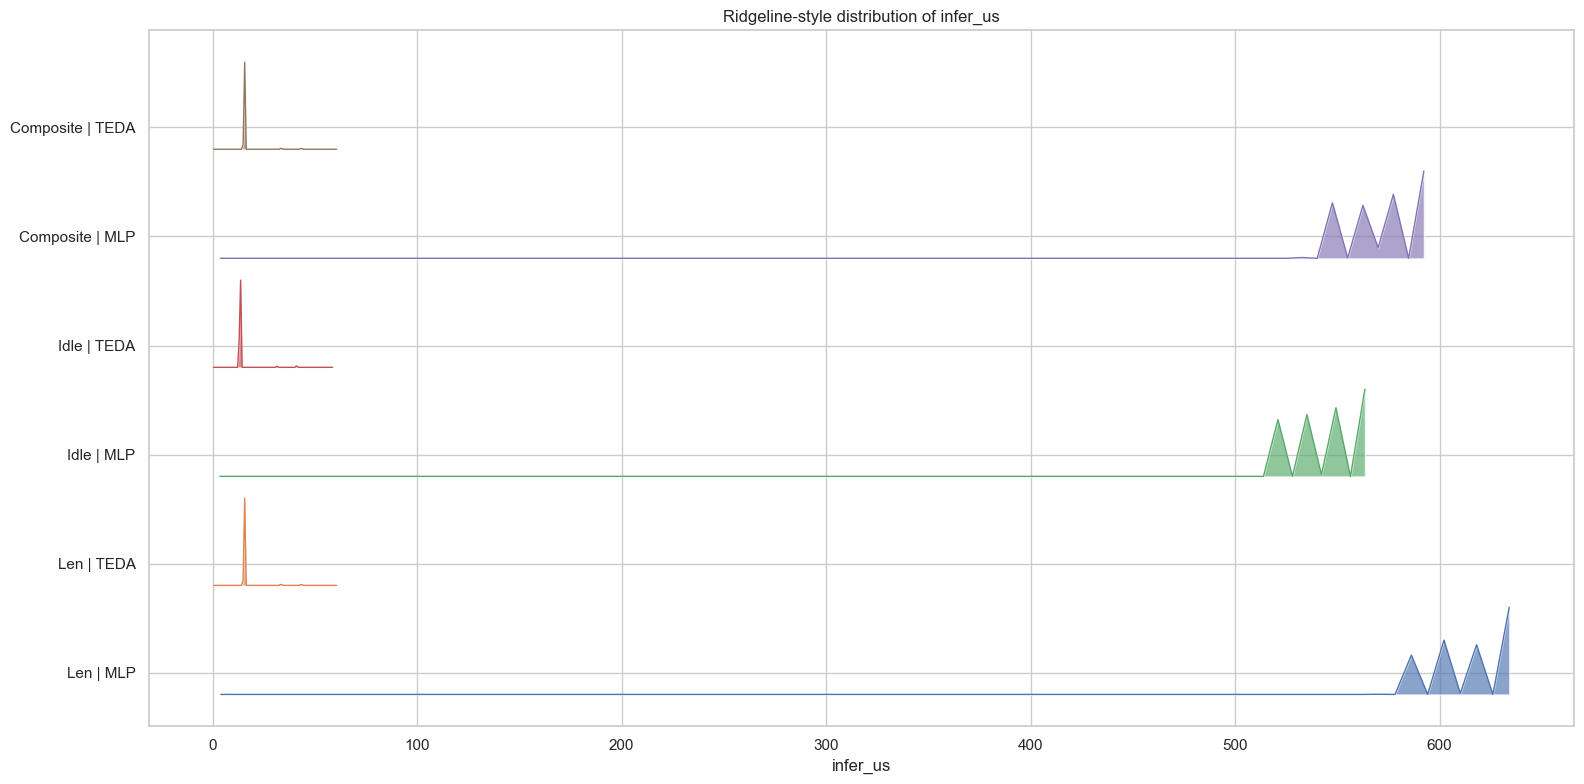

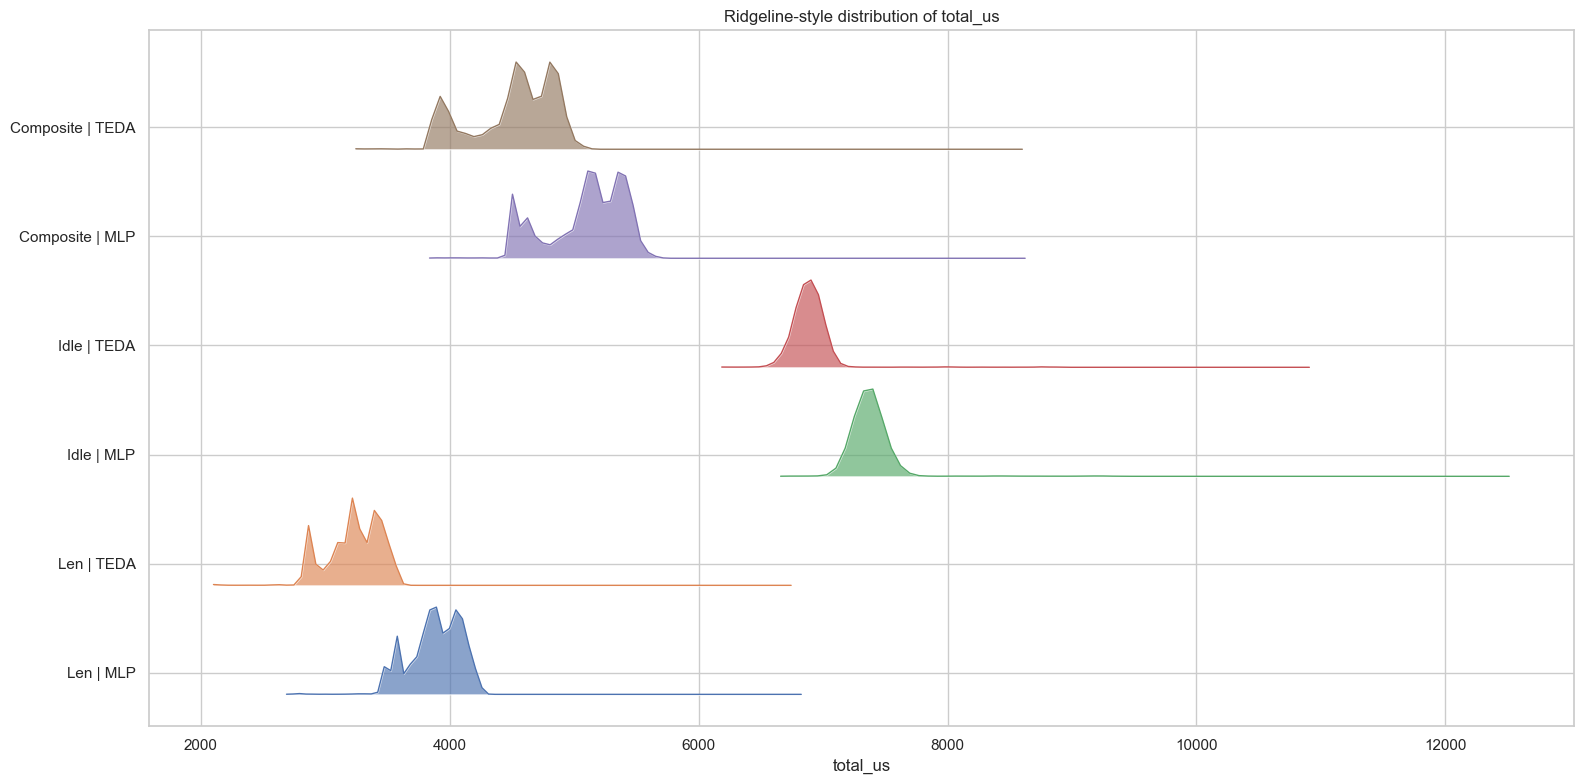

In [89]:
def ridgeline_plot(metric: str, title: str):
    groups = []
    labels = []
    for rep_name in rep_order:
        for model_name in ['MLP', 'TEDA']:
            values = infer_frames[(model_name, rep_name)][metric].astype(float).to_numpy()
            groups.append(values)
            labels.append(f'{rep_labels[rep_name]} | {model_name}')

    fig, ax = plt.subplots(figsize=(16, 8))
    offsets = np.arange(len(groups))
    for offset, values, label in zip(offsets, groups, labels):
        hist, edges = np.histogram(values, bins=80, density=True)
        centers = 0.5 * (edges[:-1] + edges[1:])
        hist = hist / max(hist.max(), 1e-9)
        ax.fill_between(centers, offset, offset + hist * 0.8, alpha=0.65)
        ax.plot(centers, offset + hist * 0.8, linewidth=1)
    ax.set_yticks(offsets + 0.2)
    ax.set_yticklabels(labels)
    ax.set_xlabel(metric)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

ridgeline_plot('infer_us', 'Ridgeline-style distribution of infer_us')
ridgeline_plot('total_us', 'Ridgeline-style distribution of total_us')

### Beeswarm-Style Latency View

A point-based view to expose spread, density, and outliers in inference time.

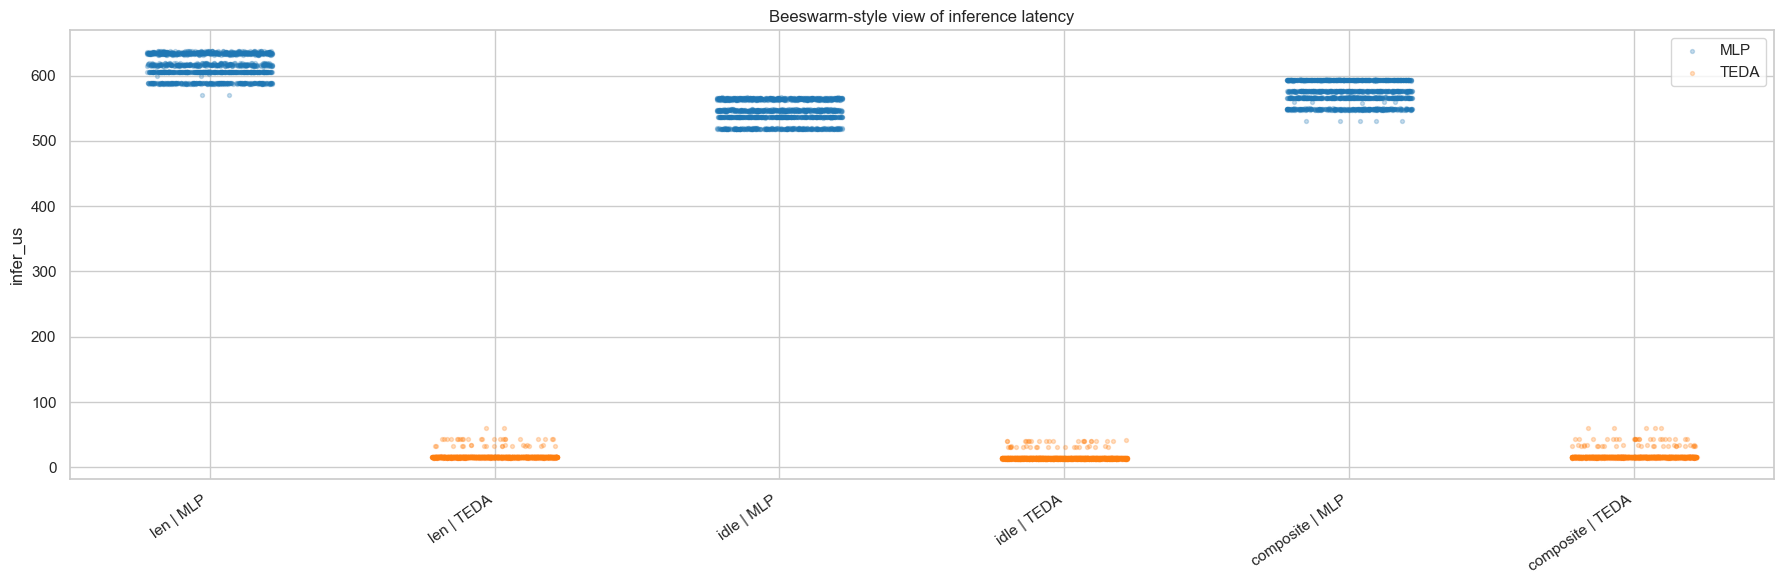

In [90]:
rng = np.random.default_rng(42)
rows = []
for rep_name in rep_order:
    for model_name in ['MLP', 'TEDA']:
        vals = infer_frames[(model_name, rep_name)]['infer_us'].astype(float)
        sample = vals.sample(n=min(1500, len(vals)), random_state=42)
        for v in sample:
            rows.append({'representacao': rep_name, 'modelo': model_name, 'infer_us': float(v)})
beeswarm_df = pd.DataFrame(rows)
beeswarm_df['x_cat'] = beeswarm_df['representacao'] + ' | ' + beeswarm_df['modelo']
order = [f'{rep} | {model}' for rep in rep_order for model in ['MLP', 'TEDA']]
cat_to_x = {cat: i for i, cat in enumerate(order)}
beeswarm_df['x'] = beeswarm_df['x_cat'].map(cat_to_x).astype(float)
beeswarm_df['jitter'] = rng.uniform(-0.22, 0.22, size=len(beeswarm_df))

plt.figure(figsize=(18, 6))
for model_name, color in model_colors.items():
    sub = beeswarm_df[beeswarm_df['modelo'] == model_name]
    plt.scatter(sub['x'] + sub['jitter'], sub['infer_us'], s=8, alpha=0.25, color=color, label=model_name)
plt.xticks(range(len(order)), order, rotation=35, ha='right')
plt.ylabel('infer_us')
plt.title('Beeswarm-style view of inference latency')
plt.legend()
plt.tight_layout()
plt.show()

### Bump Chart: Ranking by Representation

Ranks show which model leads each representation under different evaluation metrics.

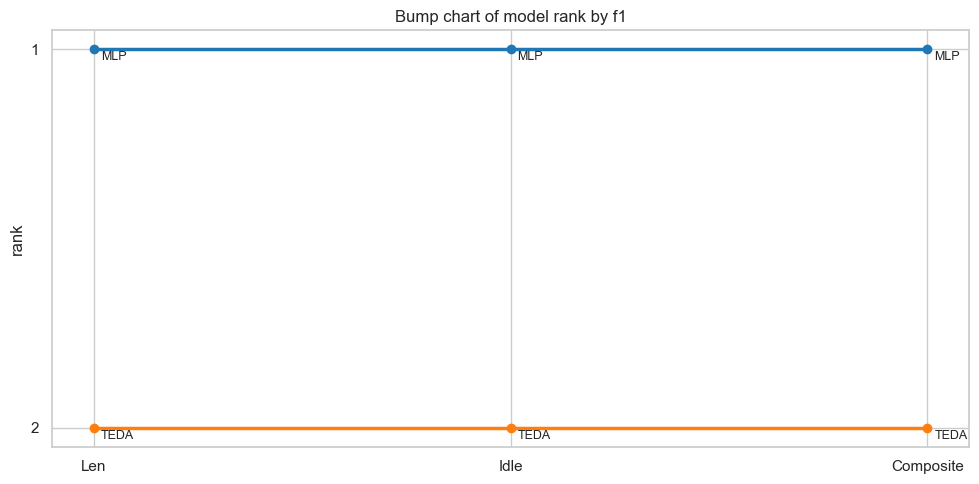

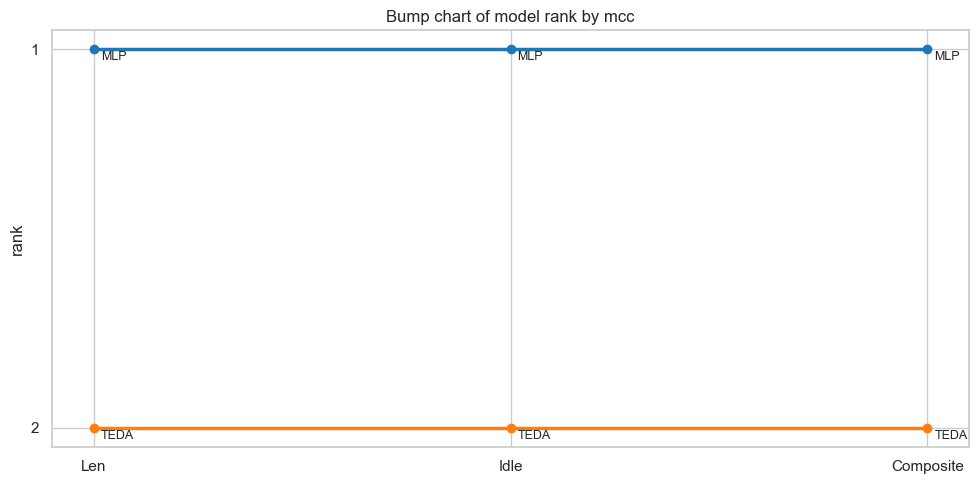

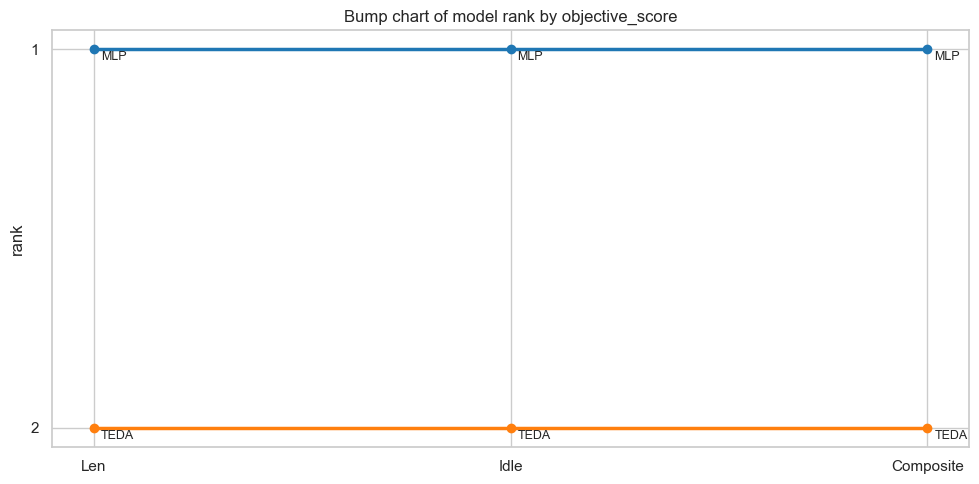

In [91]:
def plot_bump(metric: str):
    rank_rows = []
    for rep_name in rep_order:
        rep_df = results_df.loc[results_df['representacao'] == rep_name, ['modelo', metric]].copy()
        rep_df['rank'] = rep_df[metric].rank(ascending=False, method='min')
        rep_df['representacao'] = rep_name
        rank_rows.append(rep_df)
    rank_df = pd.concat(rank_rows, ignore_index=True)

    plt.figure(figsize=(10, 5))
    for model_name in ['MLP', 'TEDA']:
        sub = rank_df[rank_df['modelo'] == model_name].copy()
        sub['x'] = sub['representacao'].map({r: i for i, r in enumerate(rep_order)})
        plt.plot(sub['x'], sub['rank'], marker='o', linewidth=2.5, label=model_name, color=model_colors[model_name])
        for _, row in sub.iterrows():
            plt.annotate(model_name, (row['x'], row['rank']), textcoords='offset points', xytext=(5, -8), fontsize=9)
    plt.xticks(range(len(rep_order)), [rep_labels[r] for r in rep_order])
    plt.yticks([1, 2], ['1', '2'])
    plt.gca().invert_yaxis()
    plt.ylabel('rank')
    plt.title(f'Bump chart of model rank by {metric}')
    plt.tight_layout()
    plt.show()

for metric in ['f1', 'mcc', 'objective_score']:
    plot_bump(metric)

### Alluvial-Like Flow: Ground Truth vs Model Decisions

This summarizes how anomaly windows flow from `y_true` into the final `MLP` and `TEDA` binary decisions.

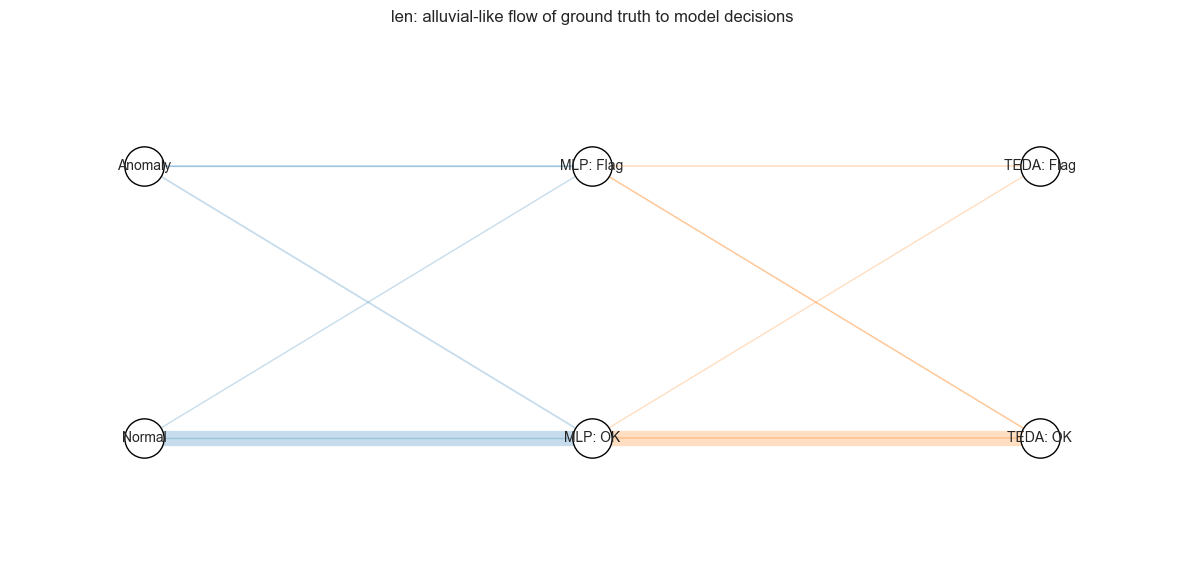

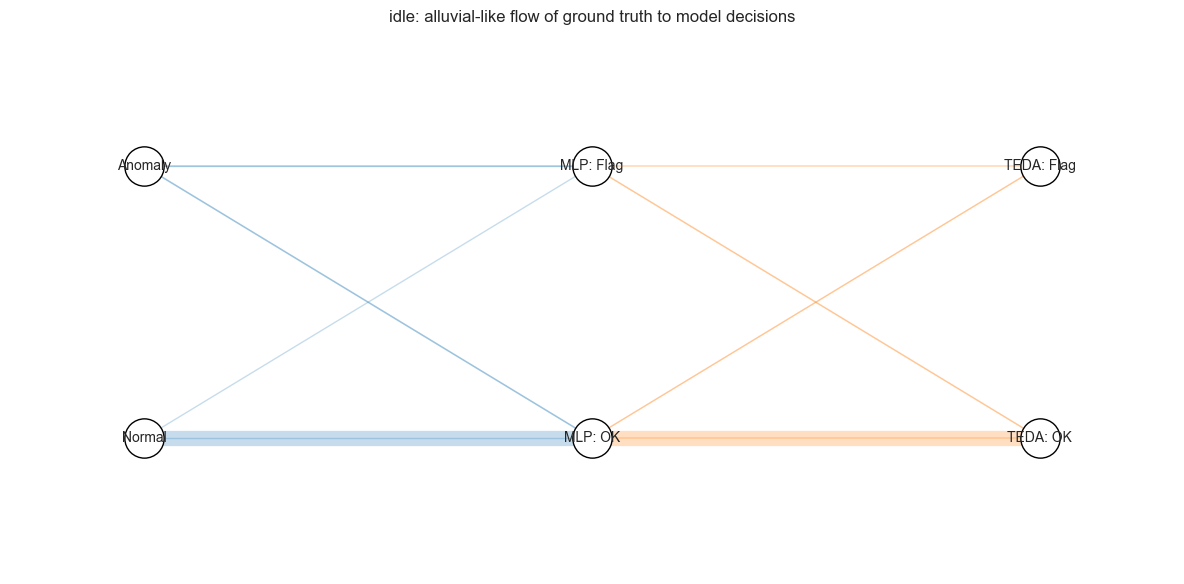

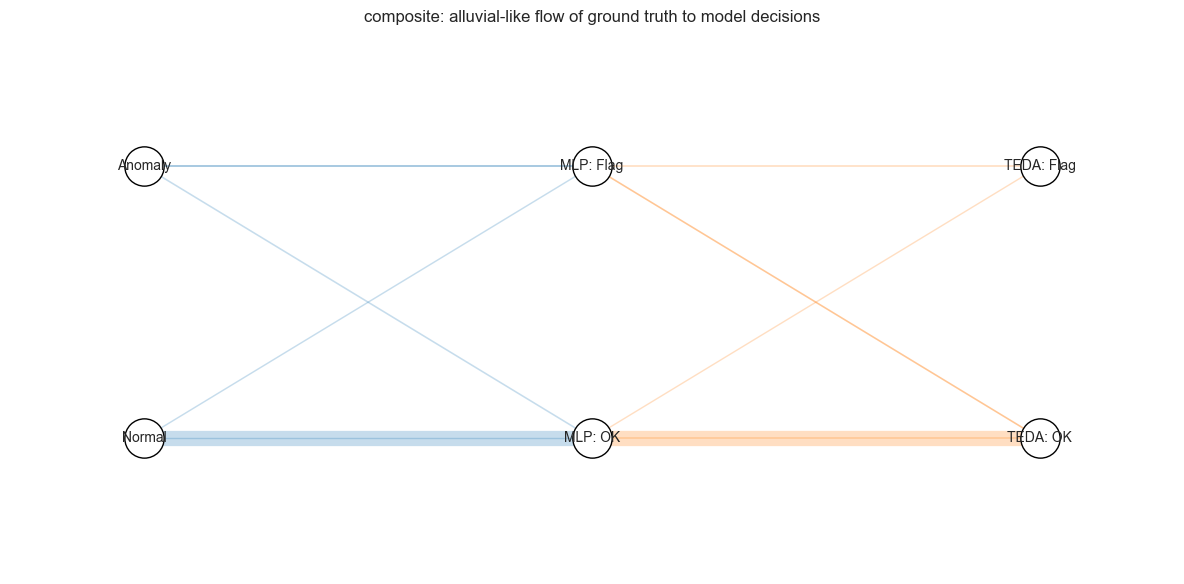

In [92]:
def plot_alluvial_like(rep_name: str):
    mlp = infer_frames[('MLP', rep_name)][['window_idx', 'y_true', 'flag']].rename(columns={'flag': 'flag_mlp'})
    teda = infer_frames[('TEDA', rep_name)][['window_idx', 'flag']].rename(columns={'flag': 'flag_teda'})
    df = mlp.merge(teda, on='window_idx', how='inner')
    flow = (
        df.assign(
            y_true=lambda d: np.where(d['y_true'] == 1, 'Anomaly', 'Normal'),
            flag_mlp=lambda d: np.where(d['flag_mlp'] == 1, 'MLP: Flag', 'MLP: OK'),
            flag_teda=lambda d: np.where(d['flag_teda'] == 1, 'TEDA: Flag', 'TEDA: OK'),
        )
        .groupby(['y_true', 'flag_mlp', 'flag_teda'])
        .size()
        .reset_index(name='count')
    )

    left_nodes = ['Normal', 'Anomaly']
    mid_nodes = ['MLP: OK', 'MLP: Flag']
    right_nodes = ['TEDA: OK', 'TEDA: Flag']
    x_map = {'left': 0, 'mid': 1, 'right': 2}
    y_map = {
        'Normal': 0, 'Anomaly': 1,
        'MLP: OK': 0, 'MLP: Flag': 1,
        'TEDA: OK': 0, 'TEDA: Flag': 1,
    }

    plt.figure(figsize=(12, 6))
    max_count = flow['count'].max()
    for _, row in flow.iterrows():
        width = 1 + 10 * row['count'] / max_count
        plt.plot([x_map['left'], x_map['mid']], [y_map[row['y_true']], y_map[row['flag_mlp']]], color='#1f77b4', alpha=0.25, linewidth=width)
        plt.plot([x_map['mid'], x_map['right']], [y_map[row['flag_mlp']], y_map[row['flag_teda']]], color='#ff7f0e', alpha=0.25, linewidth=width)

    for x, labels in zip([0, 1, 2], [left_nodes, mid_nodes, right_nodes]):
        for label in labels:
            plt.scatter([x], [y_map[label]], s=800, color='white', edgecolor='black', zorder=3)
            plt.text(x, y_map[label], label, ha='center', va='center', fontsize=10, zorder=4)

    plt.xlim(-0.3, 2.3)
    plt.ylim(-0.5, 1.5)
    plt.axis('off')
    plt.title(f'{rep_name}: alluvial-like flow of ground truth to model decisions')
    plt.tight_layout()
    plt.show()

for rep_name in rep_order:
    plot_alluvial_like(rep_name)

## Main Findings

In [93]:
summary_rows = []
for rep_name in ['len', 'idle', 'composite']:
    rep_df = results_df.loc[results_df['representacao'] == rep_name].set_index('modelo')
    best_f1_model = rep_df['f1'].idxmax()
    fastest_model = rep_df['total_us_mean'].idxmin()
    summary_rows.append({
        'representacao': rep_name,
        'best_f1_model': best_f1_model,
        'best_f1': float(rep_df.loc[best_f1_model, 'f1']),
        'best_mcc_model': rep_df['mcc'].idxmax(),
        'fastest_model': fastest_model,
        'fastest_total_us_mean': float(rep_df.loc[fastest_model, 'total_us_mean']),
        'lowest_far_model': rep_df['false_alarm_rate'].idxmin(),
        'all_complete': bool(rep_df['is_complete'].all()),
    })
summary_df = pd.DataFrame(summary_rows)
display(summary_df)

for _, row in summary_df.iterrows():
    display(Markdown(
        f"- **{row['representacao']}**: best F1 = **{row['best_f1_model']}** ({row['best_f1']:.3f}); "
        f"fastest = **{row['fastest_model']}** ({row['fastest_total_us_mean']:.1f} us mean total); "
        f"lowest FAR = **{row['lowest_far_model']}**; all complete = **{row['all_complete']}**"
    ))

,representacao,best_f1_model,best_f1,best_mcc_model,fastest_model,fastest_total_us_mean,lowest_far_model,all_complete
0,len,MLP,0.650144,MLP,TEDA,3230.647097,MLP,True
1,idle,MLP,0.804238,MLP,TEDA,6893.569277,MLP,True
2,composite,MLP,0.805833,MLP,TEDA,4508.656879,TEDA,True


- **len**: best F1 = **MLP** (0.650); fastest = **TEDA** (3230.6 us mean total); lowest FAR = **MLP**; all complete = **True**

- **idle**: best F1 = **MLP** (0.804); fastest = **TEDA** (6893.6 us mean total); lowest FAR = **MLP**; all complete = **True**

- **composite**: best F1 = **MLP** (0.806); fastest = **TEDA** (4508.7 us mean total); lowest FAR = **TEDA**; all complete = **True**